<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Aishwarya_sia_algorithm_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_excel('/content/drive/MyDrive/aishwarya preopkhkvax.xlsx')

In [3]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis
0,43.50,44.00,90,43.25,44.75,10
1,44.25,44.50,45,41.25,44.50,70
2,47.75,49.50,5,46.00,47.75,35
3,43.75,44.75,165,42.75,45.00,150
4,44.25,44.75,85,44.50,45.50,40
...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170
103,45.75,46.25,30,45.75,47.00,5
104,45.25,46.00,135,44.25,45.50,155
105,46.00,46.50,40,46.25,48.00,5


In [4]:
df.columns

Index(['pre-op KH', 'pre-op KV', 'pre-op Axis', 'post-op KH', 'post-op KV',
       'post-op Axis'],
      dtype='object')

In [5]:

# double-angle vector analysis (Pythagorean vector method)

# preop magnitude = M1 = pre-op KV-pre-op KH
# preop axis = A1
# postop magnitude = M2 = post-op KV-post-op KH
# postop axis = A2

# 1. Convert pre-op astigmatism to vector components
    # X1 = M1​*cos(2A1)
    # Y1 = M1*sin(2A1)

# 2. Convert post-op astigmatism to vector components
    # X2 = M2*cos(2A2)
    # Y2 = M2*sin(2A2)

# 3. Calculate SIA vector components:
    # Xsia = X2-X1
    # Ysia = Y2-Y1

# 4. Calculate SIA magnitude
    # SIA Magnitude = ​	sqrt*Xsia*2+Ysia*2

# 5. Calculate SIA axis (single-angle, in degrees)
    # SIA Axis = 1/2*tan inverse(Ysia/Xsia)


In [6]:
# prompt: pre_op KV -pre_op KH
# finding M1

df['M1'] = df['pre-op KV'] - df['pre-op KH']
df['M1']

,M1
0,0.50
1,0.25
2,1.75
3,1.00
4,0.50
...,...
102,0.50
103,0.50
104,0.75
105,0.50


In [7]:
# finding M2 by subtracting
# post-op KV-post-op KH

df['M2'] = df['post-op KV'] - df['post-op KH']
df['M2']

,M2
0,1.50
1,3.25
2,1.75
3,2.25
4,1.00
...,...
102,0.75
103,1.25
104,1.25
105,1.75


In [8]:
# now df contains columns M1 and M2
# finding pre-op astigmatism vectors

# X1 = M1 * cos2*pre-op Axis
# Y1 = M1 * sin2*pre-op Axix

In [9]:
# prompt: M1*cos2*pre-op Axis

import numpy as np
df['X1'] = df['M1'] * np.cos(2 * np.deg2rad(df['pre-op Axis']))
df['Y1'] = df['M1'] * np.sin(2 * np.deg2rad(df['pre-op Axis']))

In [10]:
df['X1'], df['Y1']

(0     -5.000000e-01
 1      1.530808e-17
 2      1.723414e+00
 3      8.660254e-01
 4     -4.924039e-01
            ...     
 102   -4.698463e-01
 103    2.500000e-01
 104   -1.377728e-16
 105    8.682409e-02
 106   -3.830222e-01
 Name: X1, Length: 107, dtype: float64,
 0      6.123234e-17
 1      2.500000e-01
 2      3.038843e-01
 3     -5.000000e-01
 4      8.682409e-02
            ...     
 102   -1.710101e-01
 103    4.330127e-01
 104   -7.500000e-01
 105    4.924039e-01
 106   -3.213938e-01
 Name: Y1, Length: 107, dtype: float64)

In [11]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02
...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01


In [12]:
# prompt: M2*cos2*pre-op Axis
# finding post-op astigmatism vecors

import numpy as np
df['X2'] = df['M2'] * np.cos(2 * np.deg2rad(df['post-op Axis']))
df['Y2'] = df['M2'] * np.sin(2 * np.deg2rad(df['post-op Axis']))

In [13]:
df['X2'], df['Y2']

(0      1.409539
 1     -2.489644
 2      0.598535
 3      1.125000
 4      0.173648
          ...   
 102    0.704769
 103    1.231010
 104    0.803485
 105    1.723414
 106   -0.160697
 Name: X2, Length: 107, dtype: float64,
 0      0.513030
 1      2.089060
 2      1.644462
 3     -1.948557
 4      0.984808
          ...   
 102   -0.256515
 103    0.217060
 104   -0.957556
 105    0.303884
 106    0.191511
 Name: Y2, Length: 107, dtype: float64)

In [14]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808
...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884


In [15]:
df['Xsia'] = df['X2']-df['X1']
df['Ysia'] = df['Y2']-df['Y1']

In [16]:
df['Xsia'], df['Ysia']

(0      1.909539
 1     -2.489644
 2     -1.124878
 3      0.258975
 4      0.666052
          ...   
 102    1.174616
 103    0.981010
 104    0.803485
 105    1.636589
 106    0.222325
 Name: Xsia, Length: 107, dtype: float64,
 0      0.513030
 1      1.839060
 2      1.340578
 3     -1.448557
 4      0.897984
          ...   
 102   -0.085505
 103   -0.215952
 104   -0.207556
 105   -0.188520
 106    0.512905
 Name: Ysia, Length: 107, dtype: float64)

In [17]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520


In [18]:
# finding SIA magnitude

df['SIA_magnitude'] = np.sqrt(df['Xsia']**2 + df['Ysia']**2)
df['SIA_magnitude']

,SIA_magnitude
0,1.977255
1,3.095233
2,1.750000
3,1.471525
4,1.118034
...,...
102,1.177724
103,1.004498
104,0.829859
105,1.647412


In [19]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia,SIA_magnitude
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412


In [20]:
# findinf SIA axis

df['SIA_axis'] = np.arctan(df['Ysia']/df['Xsia'])
df['SIA_axis']

,SIA_axis
0,0.262469
1,-0.636219
2,-0.872665
3,-1.393884
4,0.932616
...,...
102,-0.072666
103,-0.216677
104,-0.252793
105,-0.114685


In [21]:
# prompt: Radians or degrees

import numpy as np
df['SIA_axis'] = np.rad2deg(np.arctan(df['Ysia']/df['Xsia']))
df['SIA_axis']

,SIA_axis
0,15.038369
1,-36.452677
2,-50.000000
3,-79.863688
4,53.434949
...,...
102,-4.163448
103,-12.414680
104,-14.483980
105,-6.570969


In [22]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia,SIA_magnitude,SIA_axis
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,15.038369
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,-36.452677
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,-50.000000
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,-79.863688
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,53.434949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,-4.163448
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,-12.414680
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,-14.483980
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,-6.570969


In [23]:
# prompt: SIA axis = 1/2tan inverse(Ysia/Xsia)

import numpy as np
# findinf SIA axis (corrected for the 1/2 factor and potential quadrants)

# Use arctan2 for correct quadrant handling
df['SIA_axis'] = 0.5 * np.arctan2(df['Ysia'], df['Xsia'])

# Convert to degrees
df['SIA_axis'] = np.rad2deg(df['SIA_axis'])

# Handle potential angles outside the desired range (0 to 180 degrees)
# Add 180 if the angle is negative to bring it into the 0-180 range
df['SIA_axis'] = df['SIA_axis'].apply(lambda x: x + 180 if x < 0 else x)

# If the axis is 0 (due to Xsia=0 and Ysia=0), leave it as 0. Otherwise, ensure it's not 180.
# This handles cases where SIA_axis might become 180 when Ysia is 0.
df['SIA_axis'] = df.apply(lambda row: 0 if (row['Xsia'] == 0 and row['Ysia'] == 0) else (row['SIA_axis'] % 180), axis=1)

df['SIA_axis']
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia,SIA_magnitude,SIA_axis
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,7.519184
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,71.773661
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,65.000000
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,140.068156
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,26.717474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,177.918276
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,173.792660
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,172.758010
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,176.714516


In [24]:
df['SIA-axis'] = 0.5 * np.arctanh(df['Ysia']/df['Xsia'])
df['SIA-axis'] = np.rad2deg(df['SIA-axis'])

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [25]:
df['SIA-axis']

,SIA-axis
0,7.890392
1,-27.146053
2,NaN
3,NaN
4,NaN
...,...
102,-2.089091
103,-6.411276
104,-7.571829
105,-3.314678


In [26]:
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia,SIA_magnitude,SIA_axis,SIA-axis
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,7.519184,7.890392
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,71.773661,-27.146053
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,65.000000,NaN
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,140.068156,NaN
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,26.717474,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,177.918276,-2.089091
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,173.792660,-6.411276
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,172.758010,-7.571829
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,176.714516,-3.314678


In [27]:
import numpy as np

# Use np.arctan2 for correct quadrant handling and vectorized calculation
df['sia_axis'] = 0.5 * np.arctan2(df['Ysia'], df['Xsia'])

# Convert to degrees using np.rad2deg
df['sia_axis'] = np.rad2deg(df['sia_axis'])

# Ensure the axis is in the 0-180 range by taking the modulo 180
# This handles both negative angles and angles > 180
# For the specific case where Xsia=0 and Ysia=0 (resulting in 0 SIA magnitude and potentially an arbitrary axis),
# the arctan2 will return 0, and 0 % 180 is 0, which is the desired behavior.
df['sia_axis'] = df['sia_axis'] % 180

df['sia_axis']
df

,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,M1,M2,X1,Y1,X2,Y2,Xsia,Ysia,SIA_magnitude,SIA_axis,SIA-axis,sia_axis
0,43.50,44.00,90,43.25,44.75,10,0.50,1.50,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,7.519184,7.890392,7.519184
1,44.25,44.50,45,41.25,44.50,70,0.25,3.25,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,71.773661,-27.146053,71.773661
2,47.75,49.50,5,46.00,47.75,35,1.75,1.75,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,65.000000,NaN,65.000000
3,43.75,44.75,165,42.75,45.00,150,1.00,2.25,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,140.068156,NaN,140.068156
4,44.25,44.75,85,44.50,45.50,40,0.50,1.00,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,26.717474,NaN,26.717474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,43.00,43.50,100,43.00,43.75,170,0.50,0.75,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,177.918276,-2.089091,177.918276
103,45.75,46.25,30,45.75,47.00,5,0.50,1.25,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,173.792660,-6.411276,173.792660
104,45.25,46.00,135,44.25,45.50,155,0.75,1.25,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,172.758010,-7.571829,172.758010
105,46.00,46.50,40,46.25,48.00,5,0.50,1.75,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,176.714516,-3.314678,176.714516


In [28]:
df['SIA_magnitude'].describe()

,SIA_magnitude
count,107.000000
mean,1.786961
std,1.086317
min,0.174311
25%,1.135210
50%,1.646684
75%,2.225146
max,6.534689


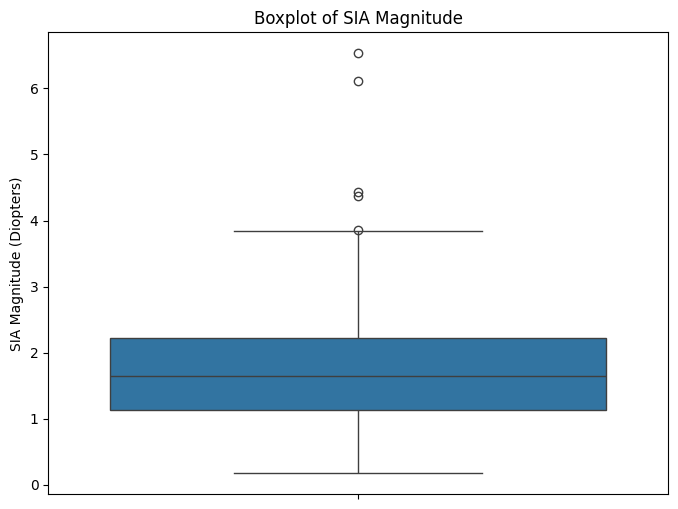

In [29]:
# prompt: Boxplot

import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot of SIA magnitude
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['SIA_magnitude'])
plt.title('Boxplot of SIA Magnitude')
plt.ylabel('SIA Magnitude (Diopters)')
plt.show()

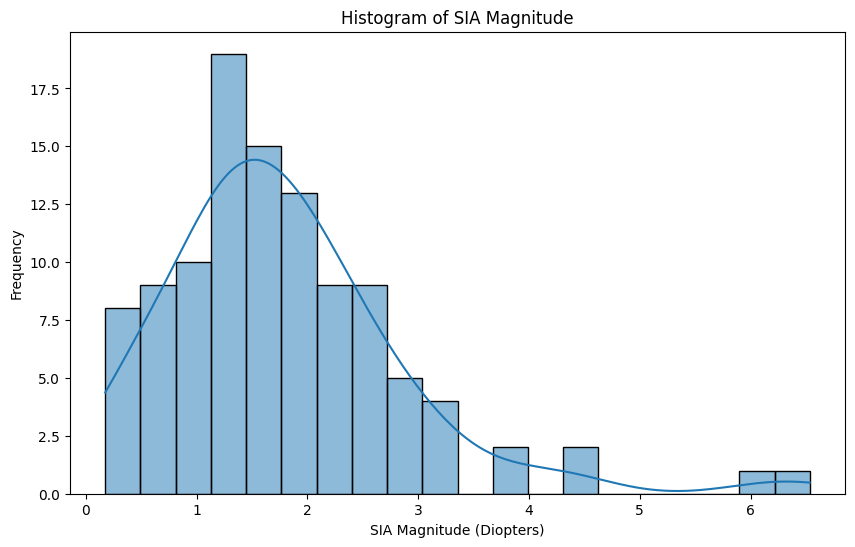

In [30]:
# prompt: Histogram

import matplotlib.pyplot as plt
# Create a histogram of SIA magnitude
plt.figure(figsize=(10, 6))
sns.histplot(df['SIA_magnitude'], kde=True, bins=20) # kde=True adds a kernel density estimate line
plt.title('Histogram of SIA Magnitude')
plt.xlabel('SIA Magnitude (Diopters)')
plt.ylabel('Frequency')
plt.show()

Mean Squared Error: 0.5227234486041382
R-squared: 0.2748151458119421
Coefficients: [ 0.09382066 -0.02017345  0.00210179  0.69571704 -0.69299423 -0.00121227]
Intercept: -3.008197959398972


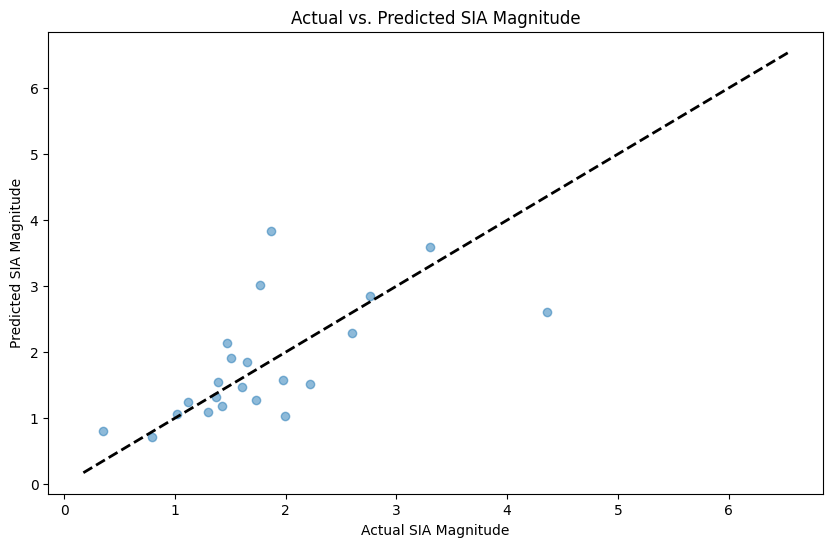

In [32]:
# prompt: Linear regression

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Define the features (independent variables) and the target (dependent variable)
# Let's try to predict SIA_magnitude based on pre-op and post-op parameters

# Drop rows with any NaN values in the relevant columns before training
df_cleaned = df.dropna(subset=['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis', 'SIA_magnitude'])

X = df_cleaned[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y = df_cleaned['SIA_magnitude'] # Target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions using the test data
y_pred = model.predict(X_test)

# Evaluate the model (optional)
from sklearn.metrics import mean_squared_error, r2_score

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

# R-squared score
r2 = r2_score(y_test, y_pred)
print(f'R-squared: {r2}')

# Print the coefficients and intercept
print(f'Coefficients: {model.coef_}')
print(f'Intercept: {model.intercept_}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude')
plt.title('Actual vs. Predicted SIA Magnitude')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()


Random Forest Mean Squared Error: 0.3977993863720148
Random Forest R-squared: 0.4481248339391892

Feature Importances:
        Feature  Importance
3    post-op KV    0.362015
4    post-op KH    0.250406
5  post-op Axis    0.118039
2   pre-op Axis    0.106742
0     pre-op KV    0.082598
1     pre-op KH    0.080200


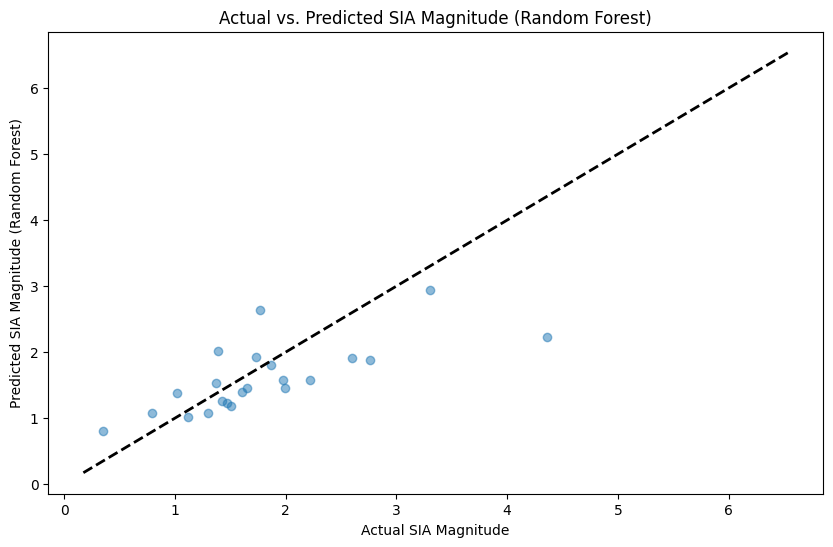

In [33]:
# prompt: Random forest

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# Create a Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # n_estimators is the number of trees in the forest

# Train the model using the training data
rf_model.fit(X_train, y_train)

# Make predictions using the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the Random Forest model

# Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'Random Forest Mean Squared Error: {mse_rf}')

# R-squared score
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest R-squared: {r2_rf}')

# Get feature importances
feature_importances = rf_model.feature_importances_
features = X.columns
importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(importances_df)

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (Random Forest)')
plt.title('Actual vs. Predicted SIA Magnitude (Random Forest)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()


SVR Mean Squared Error: 0.4420808565400526
SVR R-squared: 0.38669225123643747


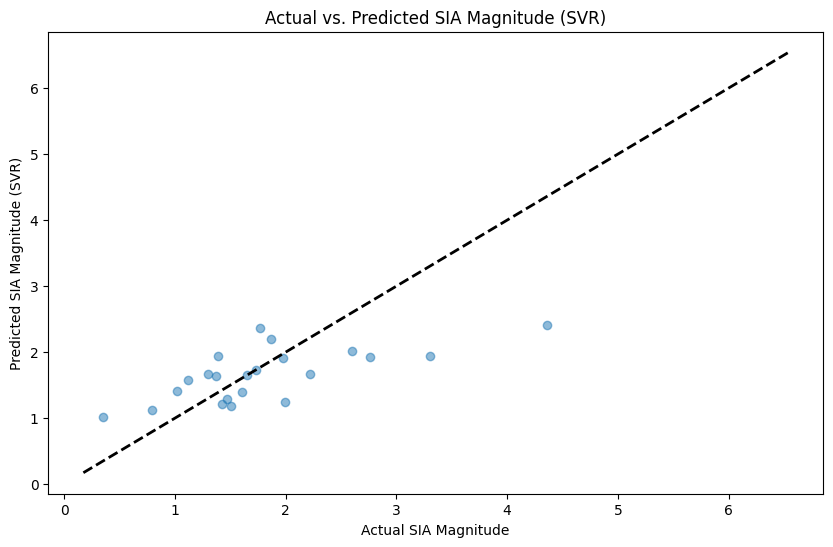

In [34]:
# prompt: Svm

import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale the features before using SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an SVR model (Support Vector Regressor)
# You can experiment with different kernels (e.g., 'linear', 'poly', 'rbf')
svm_model = SVR(kernel='rbf') # 'rbf' is a common choice for non-linear relationships

# Train the model using the scaled training data
svm_model.fit(X_train_scaled, y_train)

# Make predictions using the scaled test data
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluate the SVR model

# Mean Squared Error (MSE)
mse_svm = mean_squared_error(y_test, y_pred_svm)
print(f'SVR Mean Squared Error: {mse_svm}')

# R-squared score
r2_svm = r2_score(y_test, y_pred_svm)
print(f'SVR R-squared: {r2_svm}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_svm, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (SVR)')
plt.title('Actual vs. Predicted SIA Magnitude (SVR)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()


Decision Tree Mean Squared Error: 0.6203859965036773
Decision Tree R-squared: 0.13932591006541928


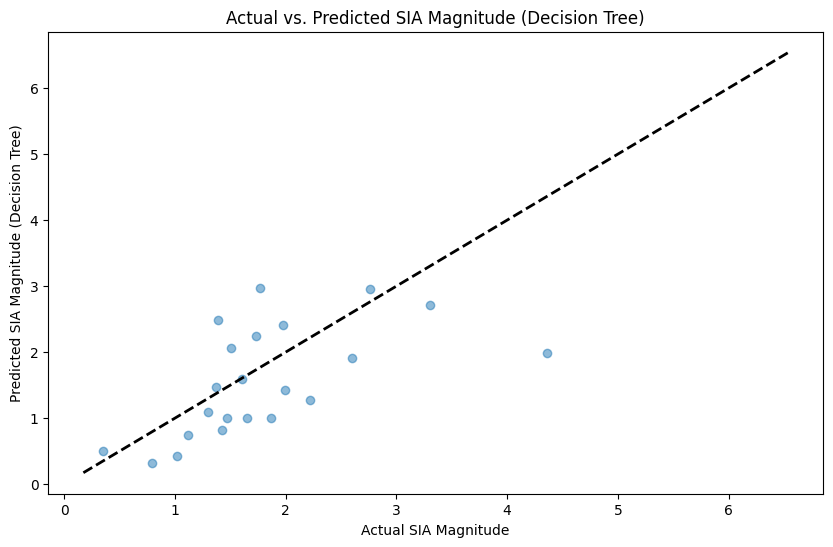

In [35]:
# prompt: Decision tree

import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Create a Decision Tree Regressor model
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
dt_model.fit(X_train, y_train)

# Make predictions using the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the Decision Tree model

# Mean Squared Error (MSE)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print(f'Decision Tree Mean Squared Error: {mse_dt}')

# R-squared score
r2_dt = r2_score(y_test, y_pred_dt)
print(f'Decision Tree R-squared: {r2_dt}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (Decision Tree)')
plt.title('Actual vs. Predicted SIA Magnitude (Decision Tree)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()

KNN Mean Squared Error: 0.7236804571344719
KNN R-squared: -0.003976592569592485


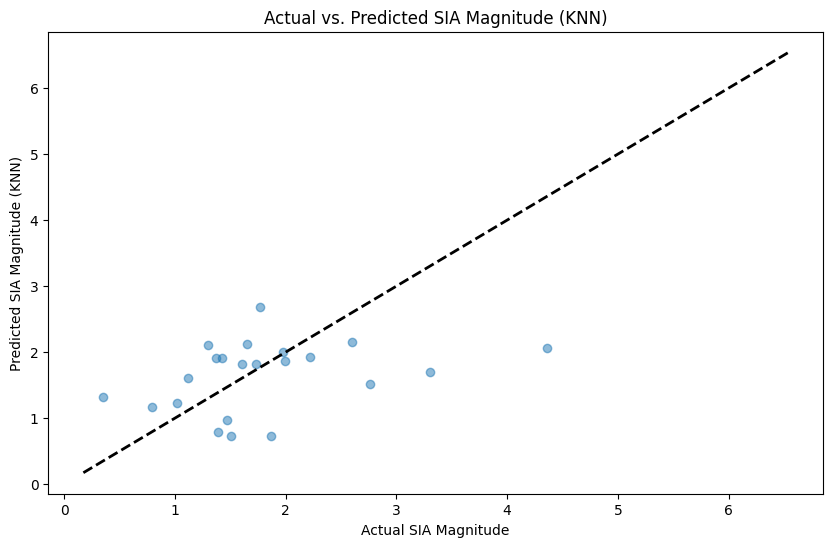

In [36]:
# prompt: Knn

import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# Create a K-Nearest Neighbors Regressor model
# You can experiment with different values for n_neighbors
knn_model = KNeighborsRegressor(n_neighbors=5) # n_neighbors is the number of neighbors to consider

# Train the model using the training data
# KNN is sensitive to scale, so using scaled data is recommended if the features have different scales.
# We can use the scaled data from the SVR section if we want, or train on the original data.
# For simplicity here, we'll train on the original data X_train.
# If scaling is important, uncomment the lines below and train on X_train_scaled:
# knn_model.fit(X_train_scaled, y_train)

knn_model.fit(X_train, y_train)


# Make predictions using the test data
# If you trained on scaled data, remember to predict on scaled test data:
# y_pred_knn = knn_model.predict(X_test_scaled)

y_pred_knn = knn_model.predict(X_test)


# Evaluate the KNN model

# Mean Squared Error (MSE)
mse_knn = mean_squared_error(y_test, y_pred_knn)
print(f'KNN Mean Squared Error: {mse_knn}')

# R-squared score
r2_knn = r2_score(y_test, y_pred_knn)
print(f'KNN R-squared: {r2_knn}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_knn, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (KNN)')
plt.title('Actual vs. Predicted SIA Magnitude (KNN)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()

XGBoost Mean Squared Error: 0.3765105071360026
XGBoost R-squared: 0.4776593283756274


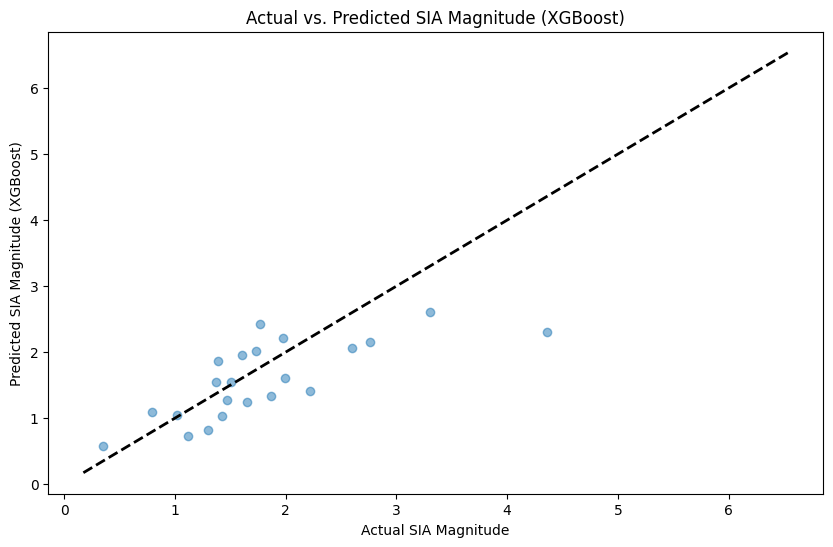

In [37]:
# prompt: XGboost

import matplotlib.pyplot as plt
!pip install xgboost
from xgboost import XGBRegressor

# Create an XGBoost Regressor model
xgb_model = XGBRegressor(objective='reg:squarederror', # Regression task
                         n_estimators=100,          # Number of boosting rounds
                         learning_rate=0.1,         # Step size shrinkage
                         max_depth=6,               # Maximum depth of a tree
                         random_state=42)           # for reproducibility

# Train the model using the training data
xgb_model.fit(X_train, y_train)

# Make predictions using the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model

# Mean Squared Error (MSE)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
print(f'XGBoost Mean Squared Error: {mse_xgb}')

# R-squared score
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'XGBoost R-squared: {r2_xgb}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (XGBoost)')
plt.title('Actual vs. Predicted SIA Magnitude (XGBoost)')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()


Polynomial Regression Mean Squared Error: 0.44737698863936187
Polynomial Regression R-squared: 0.3793448196366991


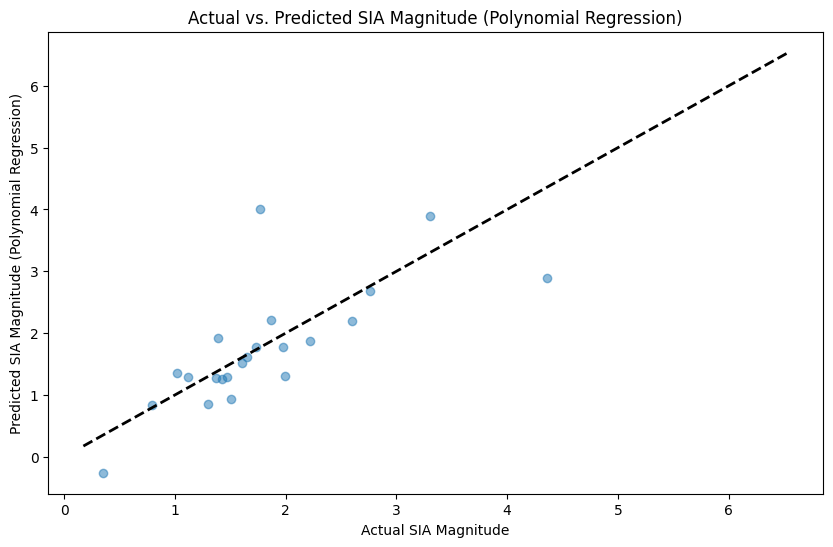

In [38]:
# prompt: Polynomials

import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# Let's focus on predicting SIA_magnitude using Polynomial Regression
# We'll still use the same cleaned data and features
X_poly = df_cleaned[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']]
y_poly = df_cleaned['SIA_magnitude']

# Split the data
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Create polynomial features
# degree=2 means it will create features like x1^2, x2^2, x1*x2, etc.
poly_features = PolynomialFeatures(degree=2)
X_train_poly_transformed = poly_features.fit_transform(X_train_poly)
X_test_poly_transformed = poly_features.transform(X_test_poly)

# Create a Linear Regression model (which will fit the polynomial features)
poly_model = LinearRegression()

# Train the model
poly_model.fit(X_train_poly_transformed, y_train_poly)

# Make predictions
y_pred_poly = poly_model.predict(X_test_poly_transformed)

# Evaluate the Polynomial Regression model

# Mean Squared Error (MSE)
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
print(f'Polynomial Regression Mean Squared Error: {mse_poly}')

# R-squared score
r2_poly = r2_score(y_test_poly, y_pred_poly)
print(f'Polynomial Regression R-squared: {r2_poly}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_poly, y_pred_poly, alpha=0.5)
plt.xlabel('Actual SIA Magnitude')
plt.ylabel('Predicted SIA Magnitude (Polynomial Regression)')
plt.title('Actual vs. Predicted SIA Magnitude (Polynomial Regression)')
plt.plot([y_poly.min(), y_poly.max()], [y_poly.min(), y_poly.max()], 'k--', lw=2) # Add a diagonal line for perfect prediction
plt.show()


Linear Regression (SIA Axis) Mean Squared Error: 0.5227234486041382
Linear Regression (SIA Axis) R-squared: 0.2748151458119421
Linear Regression (SIA Axis) Coefficients: [ 0.09382066 -0.02017345  0.00210179  0.69571704 -0.69299423 -0.00121227]
Linear Regression (SIA Axis) Intercept: -3.008197959398972


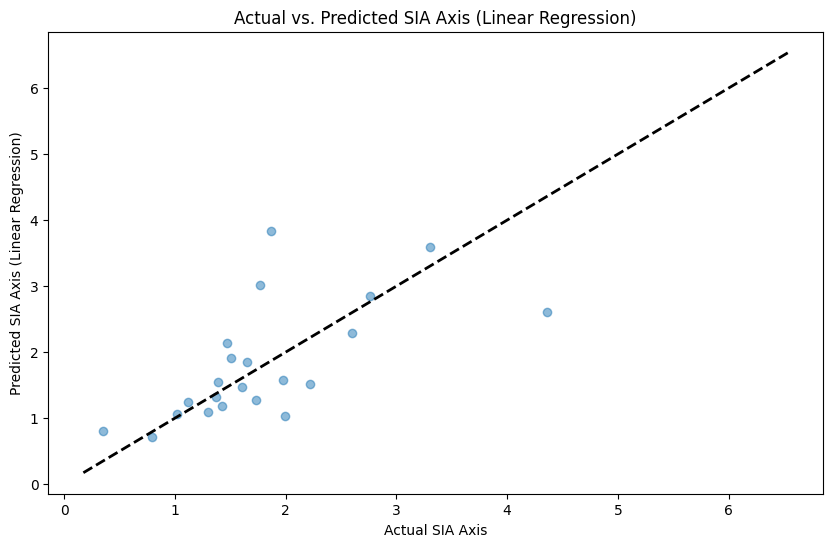

In [40]:
# prompt: OLS

import matplotlib.pyplot as plt
# OLS model to predict SIA_axis
# Drop rows with any NaN values in the relevant columns before training
# Including 'sia_axis' in the subset for cleaning
df_cleaned_axis = df.dropna(subset=['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis', 'sia_axis'])

X_axis = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis = df_cleaned_axis['SIA_magnitude'] # Target

# Split the data into training and testing sets
X_train_axis, X_test_axis, y_train_axis, y_test_axis = train_test_split(X_axis, y_axis, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a Linear Regression model for axis prediction
model_axis = LinearRegression()

# Train the model using the training data
model_axis.fit(X_train_axis, y_train_axis)

# Make predictions using the test data
y_pred_axis = model_axis.predict(X_test_axis)

# Evaluate the axis prediction model

# Mean Squared Error (MSE)
mse_axis = mean_squared_error(y_test_axis, y_pred_axis)
print(f'Linear Regression (SIA Axis) Mean Squared Error: {mse_axis}')

# R-squared score
r2_axis = r2_score(y_test_axis, y_pred_axis)
print(f'Linear Regression (SIA Axis) R-squared: {r2_axis}')

# Print the coefficients and intercept
print(f'Linear Regression (SIA Axis) Coefficients: {model_axis.coef_}')
print(f'Linear Regression (SIA Axis) Intercept: {model_axis.intercept_}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis, y_pred_axis, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (Linear Regression)')
plt.title('Actual vs. Predicted SIA Axis (Linear Regression)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis.min(), y_axis.max()], [y_axis.min(), y_axis.max()], 'k--', lw=2)
plt.show()



Linear Regression (SIA Axis) Mean Squared Error: 3644.20433096139
Linear Regression (SIA Axis) R-squared: 0.22722948922017505
Linear Regression (SIA Axis) Coefficients: [-10.33835859   2.97825096  -0.14150281   2.41780945  -0.19417494
   0.58014005]
Linear Regression (SIA Axis) Intercept: 288.37626597872054


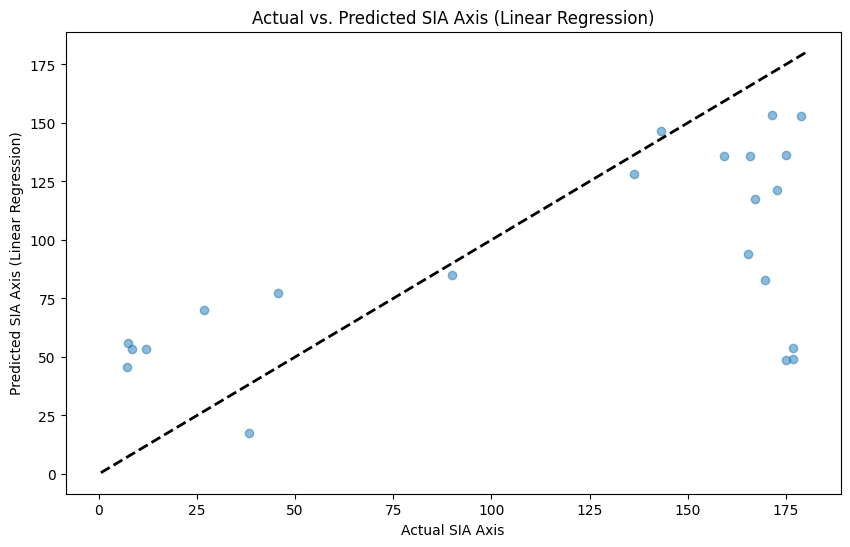

In [41]:
# prompt: Linear regression sia_axis

import matplotlib.pyplot as plt
# Corrected OLS model to predict SIA_axis
# Drop rows with any NaN values in the relevant columns before training
# Including 'sia_axis' in the subset for cleaning
df_cleaned_axis = df.dropna(subset=['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis', 'sia_axis'])

# Define features (X) and target (y) for predicting SIA_axis
X_axis = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis = df_cleaned_axis['sia_axis'] # Target is now sia_axis

# Split the data into training and testing sets
X_train_axis, X_test_axis, y_train_axis, y_test_axis = train_test_split(X_axis, y_axis, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a Linear Regression model for axis prediction
model_axis = LinearRegression()

# Train the model using the training data
model_axis.fit(X_train_axis, y_train_axis)

# Make predictions using the test data
y_pred_axis = model_axis.predict(X_test_axis)

# Evaluate the axis prediction model

# Mean Squared Error (MSE)
mse_axis = mean_squared_error(y_test_axis, y_pred_axis)
print(f'Linear Regression (SIA Axis) Mean Squared Error: {mse_axis}')

# R-squared score
r2_axis = r2_score(y_test_axis, y_pred_axis)
print(f'Linear Regression (SIA Axis) R-squared: {r2_axis}')

# Print the coefficients and intercept
print(f'Linear Regression (SIA Axis) Coefficients: {model_axis.coef_}')
print(f'Linear Regression (SIA Axis) Intercept: {model_axis.intercept_}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis, y_pred_axis, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (Linear Regression)')
plt.title('Actual vs. Predicted SIA Axis (Linear Regression)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis.min(), y_axis.max()], [y_axis.min(), y_axis.max()], 'k--', lw=2)
plt.show()


Random Forest (SIA Axis) Mean Squared Error: 1805.435057518594
Random Forest (SIA Axis) R-squared: 0.6171490825240369

Random Forest (SIA Axis) Feature Importances:
        Feature  Importance
5  post-op Axis    0.685631
2   pre-op Axis    0.114215
0     pre-op KV    0.065185
4    post-op KH    0.053004
1     pre-op KH    0.048865
3    post-op KV    0.033100


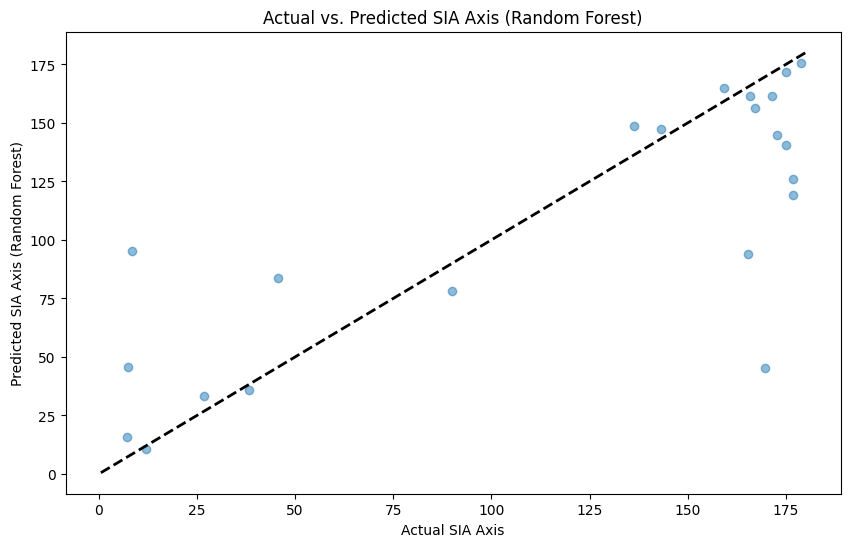

In [42]:
# prompt: Random forest

import pandas as pd
import matplotlib.pyplot as plt
# Define features (X) and target (y) for predicting SIA_axis using Random Forest
X_axis_rf = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis_rf = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Split the data into training and testing sets
X_train_axis_rf, X_test_axis_rf, y_train_axis_rf, y_test_axis_rf = train_test_split(X_axis_rf, y_axis_rf, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a Random Forest Regressor model for axis prediction
rf_model_axis = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the training data
rf_model_axis.fit(X_train_axis_rf, y_train_axis_rf)

# Make predictions using the test data
y_pred_axis_rf = rf_model_axis.predict(X_test_axis_rf)

# Evaluate the Random Forest axis prediction model

# Mean Squared Error (MSE)
mse_axis_rf = mean_squared_error(y_test_axis_rf, y_pred_axis_rf)
print(f'Random Forest (SIA Axis) Mean Squared Error: {mse_axis_rf}')

# R-squared score
r2_axis_rf = r2_score(y_test_axis_rf, y_pred_axis_rf)
print(f'Random Forest (SIA Axis) R-squared: {r2_axis_rf}')

# Get feature importances for axis prediction
feature_importances_axis = rf_model_axis.feature_importances_
features_axis = X_axis_rf.columns
importances_axis_df = pd.DataFrame({'Feature': features_axis, 'Importance': feature_importances_axis})
importances_axis_df = importances_axis_df.sort_values(by='Importance', ascending=False)

print("\nRandom Forest (SIA Axis) Feature Importances:")
print(importances_axis_df)

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis_rf, y_pred_axis_rf, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (Random Forest)')
plt.title('Actual vs. Predicted SIA Axis (Random Forest)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis_rf.min(), y_axis_rf.max()], [y_axis_rf.min(), y_axis_rf.max()], 'k--', lw=2)
plt.show()

SVR (SIA Axis) Mean Squared Error: 4324.667933493861
SVR (SIA Axis) R-squared: 0.08293401126672739


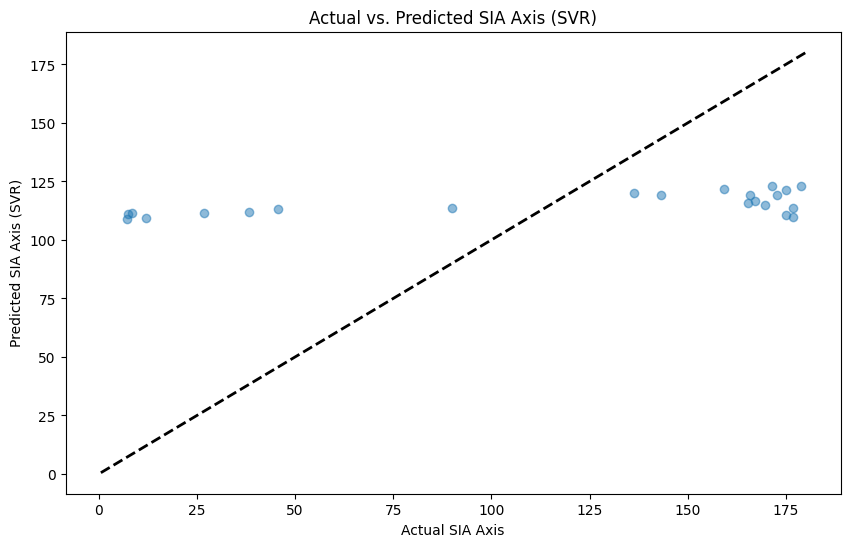

In [43]:
# prompt: Svm

import matplotlib.pyplot as plt
# Define features (X) and target (y) for predicting SIA_axis using SVR
X_axis_svm = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis_svm = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Split the data into training and testing sets
X_train_axis_svm, X_test_axis_svm, y_train_axis_svm, y_test_axis_svm = train_test_split(X_axis_svm, y_axis_svm, test_size=0.2, random_state=42) # 80% train, 20% test

# Scale the features before using SVM for axis prediction
scaler_axis = StandardScaler()
X_train_axis_scaled = scaler_axis.fit_transform(X_train_axis_svm)
X_test_axis_scaled = scaler_axis.transform(X_test_axis_svm)

# Create an SVR model for axis prediction
svm_model_axis = SVR(kernel='rbf') # 'rbf' is a common choice

# Train the model using the scaled training data
svm_model_axis.fit(X_train_axis_scaled, y_train_axis_svm)

# Make predictions using the scaled test data
y_pred_axis_svm = svm_model_axis.predict(X_test_axis_scaled)

# Evaluate the SVR axis prediction model

# Mean Squared Error (MSE)
mse_axis_svm = mean_squared_error(y_test_axis_svm, y_pred_axis_svm)
print(f'SVR (SIA Axis) Mean Squared Error: {mse_axis_svm}')

# R-squared score
r2_axis_svm = r2_score(y_test_axis_svm, y_pred_axis_svm)
print(f'SVR (SIA Axis) R-squared: {r2_axis_svm}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis_svm, y_pred_axis_svm, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (SVR)')
plt.title('Actual vs. Predicted SIA Axis (SVR)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis_svm.min(), y_axis_svm.max()], [y_axis_svm.min(), y_axis_svm.max()], 'k--', lw=2)
plt.show()


Decision Tree (SIA Axis) Mean Squared Error: 2809.0044505866726
Decision Tree (SIA Axis) R-squared: 0.40433751597841916

Decision Tree (SIA Axis) Feature Importances:
        Feature  Importance
5  post-op Axis    0.619584
0     pre-op KV    0.223285
2   pre-op Axis    0.110274
4    post-op KH    0.023768
1     pre-op KH    0.019503
3    post-op KV    0.003585


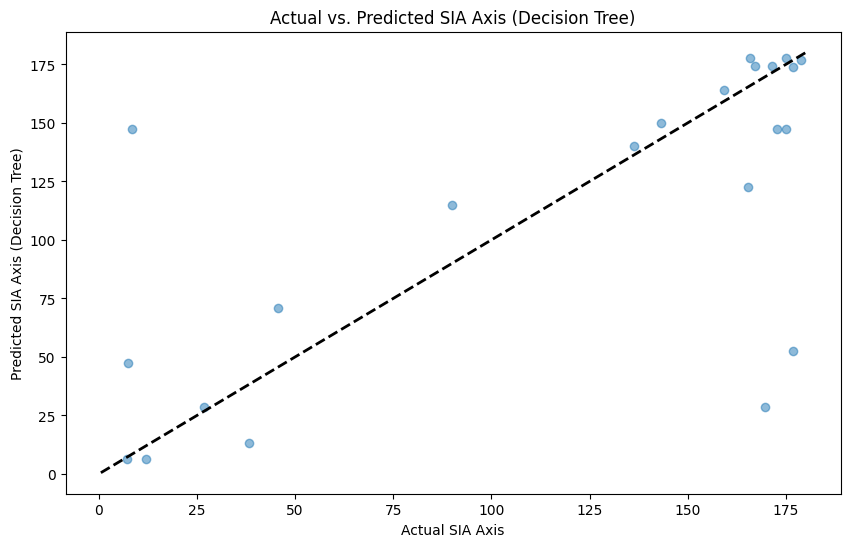

In [44]:
# prompt: Decision tree

import pandas as pd
import matplotlib.pyplot as plt
# Define features (X) and target (y) for predicting SIA_axis using Decision Tree
X_axis_dt = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis_dt = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Split the data into training and testing sets
X_train_axis_dt, X_test_axis_dt, y_train_axis_dt, y_test_axis_dt = train_test_split(X_axis_dt, y_axis_dt, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a Decision Tree Regressor model for axis prediction
dt_model_axis = DecisionTreeRegressor(random_state=42)

# Train the model using the training data
dt_model_axis.fit(X_train_axis_dt, y_train_axis_dt)

# Make predictions using the test data
y_pred_axis_dt = dt_model_axis.predict(X_test_axis_dt)

# Evaluate the Decision Tree axis prediction model

# Mean Squared Error (MSE)
mse_axis_dt = mean_squared_error(y_test_axis_dt, y_pred_axis_dt)
print(f'Decision Tree (SIA Axis) Mean Squared Error: {mse_axis_dt}')

# R-squared score
r2_axis_dt = r2_score(y_test_axis_dt, y_pred_axis_dt)
print(f'Decision Tree (SIA Axis) R-squared: {r2_axis_dt}')

# Get feature importances for axis prediction
feature_importances_axis_dt = dt_model_axis.feature_importances_
features_axis_dt = X_axis_dt.columns
importances_axis_df_dt = pd.DataFrame({'Feature': features_axis_dt, 'Importance': feature_importances_axis_dt})
importances_axis_df_dt = importances_axis_df_dt.sort_values(by='Importance', ascending=False)

print("\nDecision Tree (SIA Axis) Feature Importances:")
print(importances_axis_df_dt)


# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis_dt, y_pred_axis_dt, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (Decision Tree)')
plt.title('Actual vs. Predicted SIA Axis (Decision Tree)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis_dt.min(), y_axis_dt.max()], [y_axis_dt.min(), y_axis_dt.max()], 'k--', lw=2)
plt.show()


KNN (SIA Axis) Mean Squared Error: 3554.542389484607
KNN (SIA Axis) R-squared: 0.24624272174499484


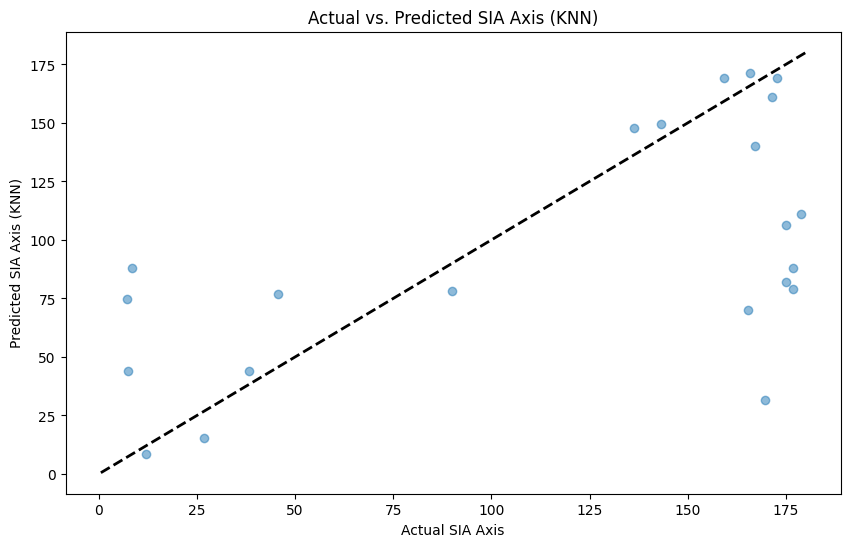

In [45]:
# prompt: Knn

import matplotlib.pyplot as plt
# Define features (X) and target (y) for predicting SIA_axis using K-Nearest Neighbors
X_axis_knn = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis_knn = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Split the data into training and testing sets
X_train_axis_knn, X_test_axis_knn, y_train_axis_knn, y_test_axis_knn = train_test_split(X_axis_knn, y_axis_knn, test_size=0.2, random_state=42) # 80% train, 20% test

# Create a K-Nearest Neighbors Regressor model for axis prediction
# You can experiment with different values for n_neighbors
knn_model_axis = KNeighborsRegressor(n_neighbors=5) # n_neighbors is the number of neighbors to consider

# Train the model using the training data
# KNN is sensitive to scale, so using scaled data is recommended if the features have different scales.
# We can use the scaled data if needed, but here we'll train on the original data for simplicity.
# knn_model_axis.fit(X_train_axis_scaled, y_train_axis_knn)

knn_model_axis.fit(X_train_axis_knn, y_train_axis_knn)

# Make predictions using the test data
# If you trained on scaled data, remember to predict on scaled test data:
# y_pred_axis_knn = knn_model_axis.predict(X_test_axis_scaled)

y_pred_axis_knn = knn_model_axis.predict(X_test_axis_knn)

# Evaluate the KNN axis prediction model

# Mean Squared Error (MSE)
mse_axis_knn = mean_squared_error(y_test_axis_knn, y_pred_axis_knn)
print(f'KNN (SIA Axis) Mean Squared Error: {mse_axis_knn}')

# R-squared score
r2_axis_knn = r2_score(y_test_axis_knn, y_pred_axis_knn)
print(f'KNN (SIA Axis) R-squared: {r2_axis_knn}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis_knn, y_pred_axis_knn, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (KNN)')
plt.title('Actual vs. Predicted SIA Axis (KNN)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis_knn.min(), y_axis_knn.max()], [y_axis_knn.min(), y_axis_knn.max()], 'k--', lw=2)
plt.show()

XGBoost (SIA Axis) Mean Squared Error: 2126.9265095950486
XGBoost (SIA Axis) R-squared: 0.5489753219251279


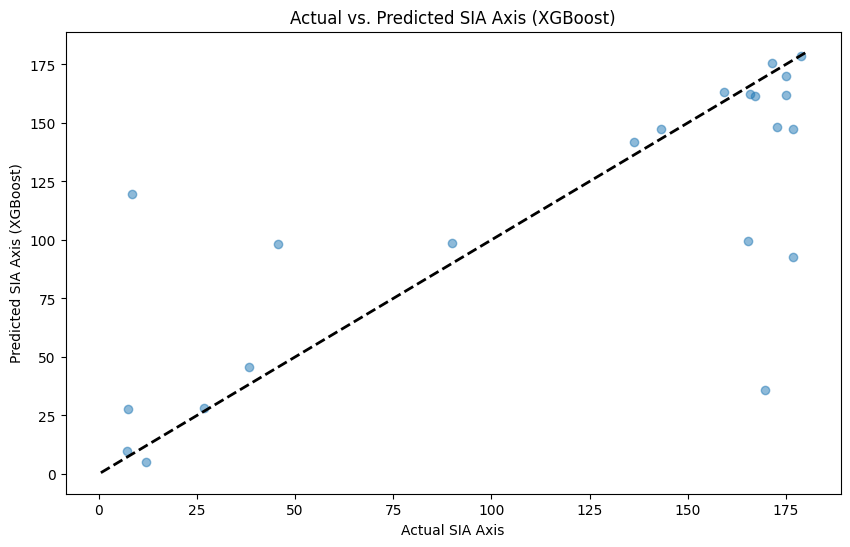

In [46]:
# prompt: XGboost

import matplotlib.pyplot as plt
# Define features (X) and target (y) for predicting SIA_axis using XGBoost
X_axis_xgb = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_axis_xgb = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Split the data into training and testing sets
X_train_axis_xgb, X_test_axis_xgb, y_train_axis_xgb, y_test_axis_xgb = train_test_split(X_axis_xgb, y_axis_xgb, test_size=0.2, random_state=42) # 80% train, 20% test

# Create an XGBoost Regressor model for axis prediction
xgb_model_axis = XGBRegressor(objective='reg:squarederror', # Regression task
                              n_estimators=100,          # Number of boosting rounds
                              learning_rate=0.1,         # Step size shrinkage
                              max_depth=6,               # Maximum depth of a tree
                              random_state=42)           # for reproducibility

# Train the model using the training data
xgb_model_axis.fit(X_train_axis_xgb, y_train_axis_xgb)

# Make predictions using the test data
y_pred_axis_xgb = xgb_model_axis.predict(X_test_axis_xgb)

# Evaluate the XGBoost axis prediction model

# Mean Squared Error (MSE)
mse_axis_xgb = mean_squared_error(y_test_axis_xgb, y_pred_axis_xgb)
print(f'XGBoost (SIA Axis) Mean Squared Error: {mse_axis_xgb}')

# R-squared score
r2_axis_xgb = r2_score(y_test_axis_xgb, y_pred_axis_xgb)
print(f'XGBoost (SIA Axis) R-squared: {r2_axis_xgb}')

# Plotting predictions vs actual values (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_axis_xgb, y_pred_axis_xgb, alpha=0.5)
plt.xlabel('Actual SIA Axis')
plt.ylabel('Predicted SIA Axis (XGBoost)')
plt.title('Actual vs. Predicted SIA Axis (XGBoost)')
# Add a diagonal line for perfect prediction
plt.plot([y_axis_xgb.min(), y_axis_xgb.max()], [y_axis_xgb.min(), y_axis_xgb.max()], 'k--', lw=2)
plt.show()


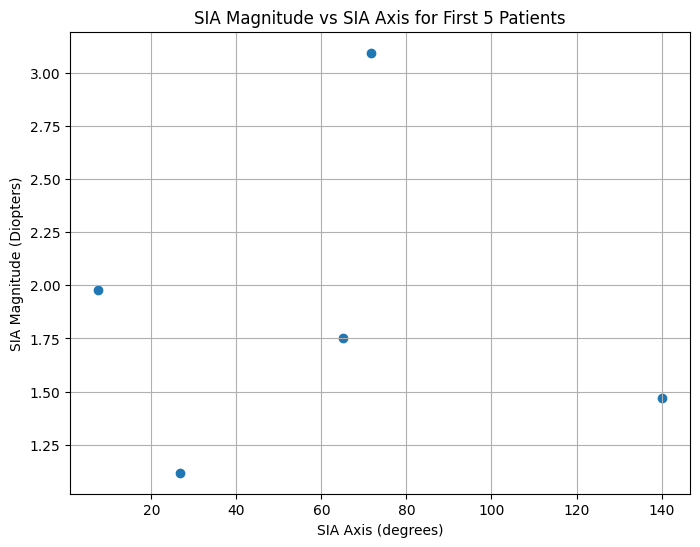

In [47]:
# prompt: Plot sia magnitude and sia axis for 5 patients

import matplotlib.pyplot as plt
# Select the first 5 patients
df_subset = df.head(5)

# Create the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df_subset['SIA_axis'], df_subset['SIA_magnitude'])
plt.xlabel('SIA Axis (degrees)')
plt.ylabel('SIA Magnitude (Diopters)')
plt.title('SIA Magnitude vs SIA Axis for First 5 Patients')
plt.grid(True)
plt.show()

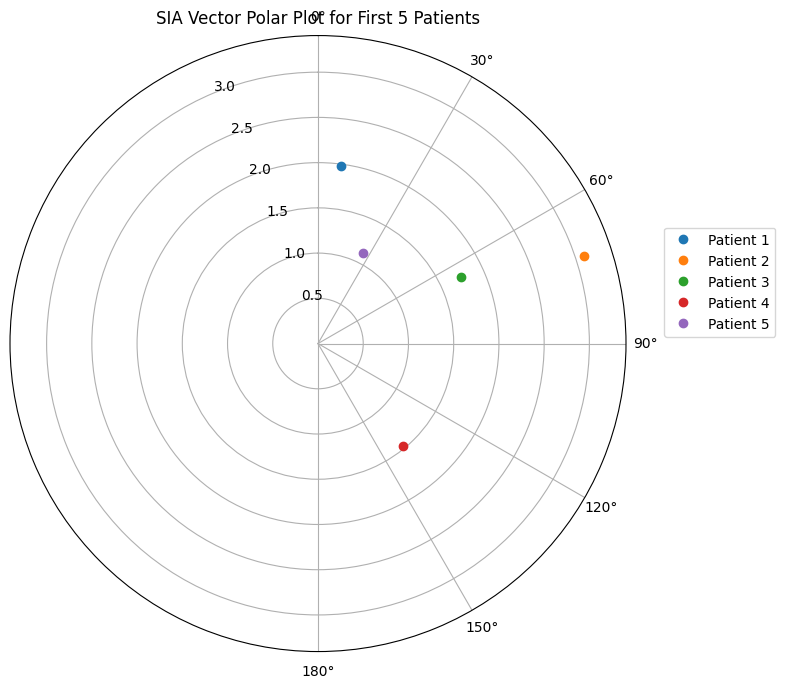

In [48]:
# prompt: Plot sia vector for 5 patients

import matplotlib.pyplot as plt
import numpy as np
# Polar plot for SIA vectors of the first 5 patients

# Select the first 5 patients
df_subset_polar = df.head(5).copy() # Create a copy to avoid SettingWithCopyWarning

# Convert SIA axis from degrees to radians for polar plot
df_subset_polar['SIA_axis_rad'] = np.deg2rad(df_subset_polar['SIA_axis'])

# Create a polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, projection='polar')

# Plot each patient's SIA vector
for i in range(len(df_subset_polar)):
  magnitude = df_subset_polar.iloc[i]['SIA_magnitude']
  axis_rad = df_subset_polar.iloc[i]['SIA_axis_rad']
  patient_label = f'Patient {i+1}'
  # Plot a single point
  ax.plot(axis_rad, magnitude, 'o', label=patient_label)

# Set the plot limits and labels
ax.set_theta_zero_location("N")  # Set 0 degrees to the top
ax.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
ax.set_thetagrids(np.arange(0, 181, 30)) # Set grid lines at 30 degree intervals
ax.set_rlabel_position(-22.5)      # Position radial labels
ax.set_title("SIA Vector Polar Plot for First 5 Patients", va='bottom')
ax.legend(loc='lower left', bbox_to_anchor=(1.05, 0.5)) # Add legend outside the plot

# Set radial limits (magnitude)
# Adjust based on your data's magnitude range if needed
ax.set_rmax(df_subset_polar['SIA_magnitude'].max() * 1.1) # Set max radial limit slightly above max magnitude
ax.grid(True)

plt.show()

SIA Vector for Patient Index 0:
  Xsia (horizontal component): 1.9095
  Ysia (vertical component): 0.5130
  SIA Magnitude: 1.9773 Diopters
  SIA Axis: 7.52 degrees


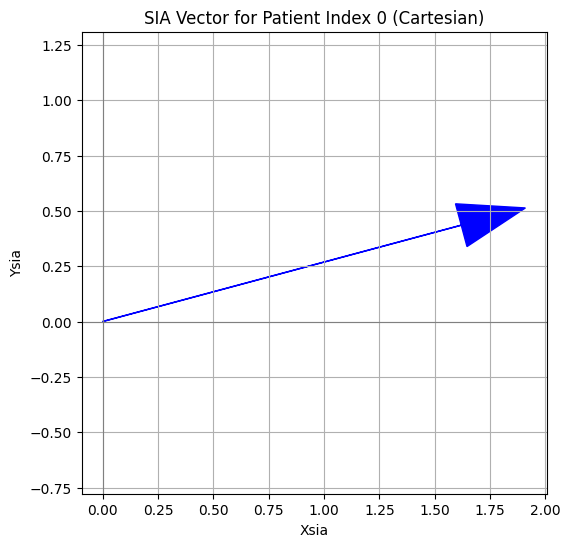

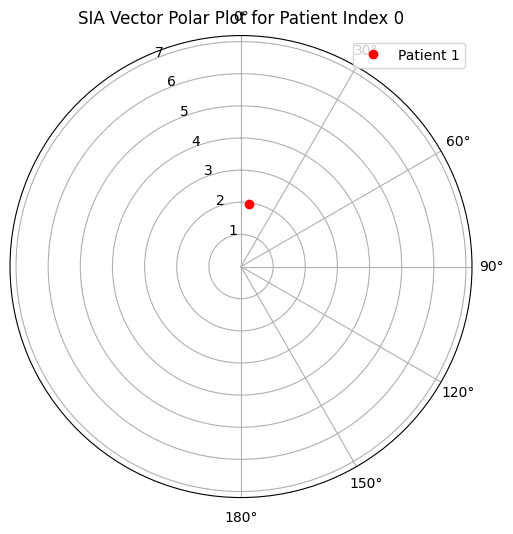

In [62]:
# prompt: SIA vector for single patient

import matplotlib.pyplot as plt
import numpy as np
# Get the data for a single patient (e.g., the first patient in the dataframe)
patient_index = 0 # You can change this to select a different patient
single_patient_data = df.iloc[patient_index]

# Extract the calculated SIA vector components and magnitude/axis for this patient
patient_Xsia = single_patient_data['Xsia']
patient_Ysia = single_patient_data['Ysia']
patient_SIA_magnitude = single_patient_data['SIA_magnitude']
patient_SIA_axis = single_patient_data['sia_axis'] # Use the corrected 'sia_axis'

# Print the SIA vector components and magnitude/axis for the single patient
print(f"SIA Vector for Patient Index {patient_index}:")
print(f"  Xsia (horizontal component): {patient_Xsia:.4f}")
print(f"  Ysia (vertical component): {patient_Ysia:.4f}")
print(f"  SIA Magnitude: {patient_SIA_magnitude:.4f} Diopters")
print(f"  SIA Axis: {patient_SIA_axis:.2f} degrees")

# Optional: Visualize the SIA vector for the single patient on a 2D Cartesian plane
plt.figure(figsize=(6, 6))
plt.arrow(0, 0, patient_Xsia, patient_Ysia, head_width=0.2, head_length=0.3, fc='blue', ec='blue', length_includes_head=True)
plt.xlabel('Xsia')
plt.ylabel('Ysia')
plt.title(f'SIA Vector for Patient Index {patient_index} (Cartesian)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling for X and Y axes
plt.show()

# Optional: Visualize the SIA vector for the single patient on a polar plot
# Convert axis to radians for polar plot
patient_SIA_axis_rad = np.deg2rad(patient_SIA_axis)

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

# Plot the vector as a point
ax.plot(patient_SIA_axis_rad, patient_SIA_magnitude, 'o', color='red', label=f'Patient {patient_index+1}')

# You can also draw an arrow from the origin if desired
# ax.arrow(0, 0, patient_SIA_axis_rad, patient_SIA_magnitude, head_width=0.05 * patient_SIA_magnitude, head_length=0.1 * patient_SIA_magnitude, fc='red', ec='red', length_includes_head=True)


# Set the plot limits and labels
ax.set_theta_zero_location("N")  # Set 0 degrees to the top
ax.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
ax.set_thetagrids(np.arange(0, 181, 30)) # Set grid lines at 30 degree intervals
ax.set_rlabel_position(-22.5)      # Position radial labels
ax.set_title(f"SIA Vector Polar Plot for Patient Index {patient_index}", va='bottom')
ax.legend(loc='upper right')

# Set radial limits (magnitude)
# Adjust based on your data's magnitude range if needed
ax.set_rmax(df['SIA_magnitude'].max() * 1.1 if not df['SIA_magnitude'].empty else 1.0) # Set max radial limit
ax.grid(True)

plt.show()

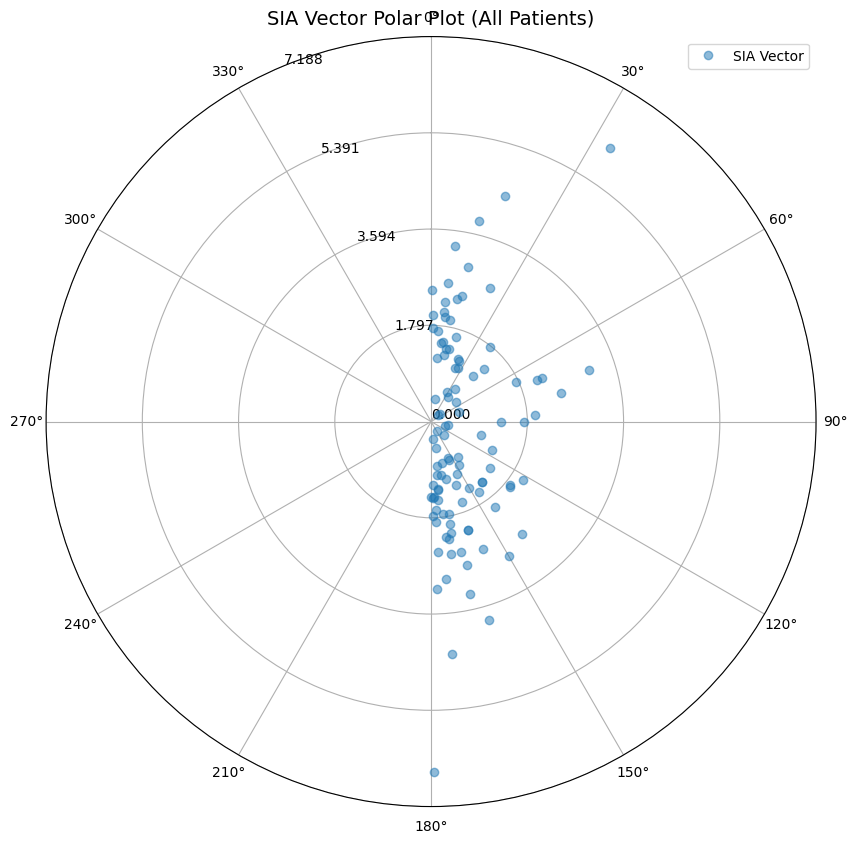

In [63]:
# prompt: Display sia magnitude and axis in the vector plot

import matplotlib.pyplot as plt
import numpy as np
# Polar plot displaying SIA magnitude and axis for all patients

# Convert SIA axis from degrees to radians for polar plot
# Ensure 'sia_axis' and 'SIA_magnitude' columns exist and are not NaN
df_plot = df.dropna(subset=['sia_axis', 'SIA_magnitude']).copy()
df_plot['sia_axis_rad'] = np.deg2rad(df_plot['sia_axis'])

# Create a polar plot
plt.figure(figsize=(10, 10))
ax = plt.subplot(111, projection='polar')

# Plot each patient's SIA vector as a point
# Use a marker to indicate each data point
ax.plot(df_plot['sia_axis_rad'], df_plot['SIA_magnitude'], 'o', alpha=0.5, label='SIA Vector') # 'o' for circle marker, alpha for transparency

# Optional: Add lines from the origin to each point to emphasize vectors
# You might want to comment this out if you have many data points as it can make the plot cluttered
# for i in range(len(df_plot)):
#    ax.plot([0, df_plot.iloc[i]['sia_axis_rad']], [0, df_plot.iloc[i]['SIA_magnitude']], color='gray', linewidth=0.5, alpha=0.3)


# Set the plot limits and labels
ax.set_theta_zero_location("N")  # Set 0 degrees to the top
ax.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
# Set thetagrids to cover the 0-180 range and potentially 180-360 if vectors can point there
# Assuming 0-180 is sufficient based on the calculation, but showing 0-360 for clarity of the polar plane
ax.set_thetagrids(np.arange(0, 360, 30)) # Set grid lines at 30 degree intervals from 0 to 360
ax.set_rlabel_position(-22.5)      # Position radial labels
ax.set_title("SIA Vector Polar Plot (All Patients)", va='bottom', fontsize=14)
ax.legend(loc='upper right') # Add legend

# Set radial limits (magnitude)
# Adjust based on your data's magnitude range
# Set max radial limit slightly above the max magnitude in your data
max_magnitude = df_plot['SIA_magnitude'].max() if not df_plot['SIA_magnitude'].empty else 1.0
ax.set_rmax(max_magnitude * 1.1)
ax.set_rgrids(np.linspace(0, max_magnitude * 1.1, 5)) # Set radial grid lines

ax.grid(True)

plt.show()

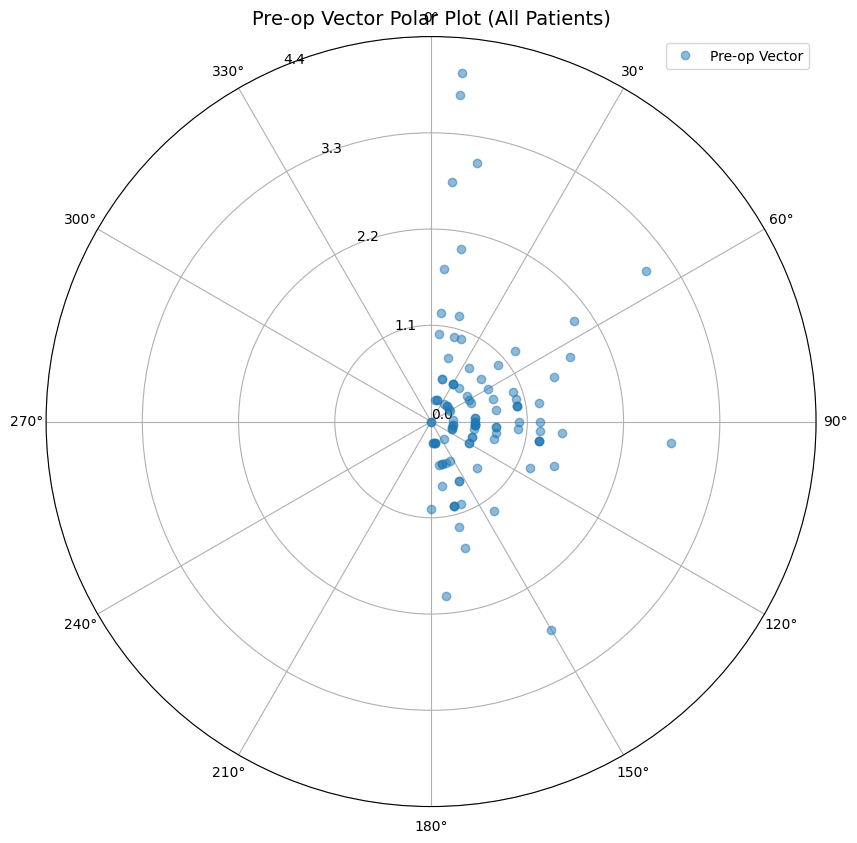

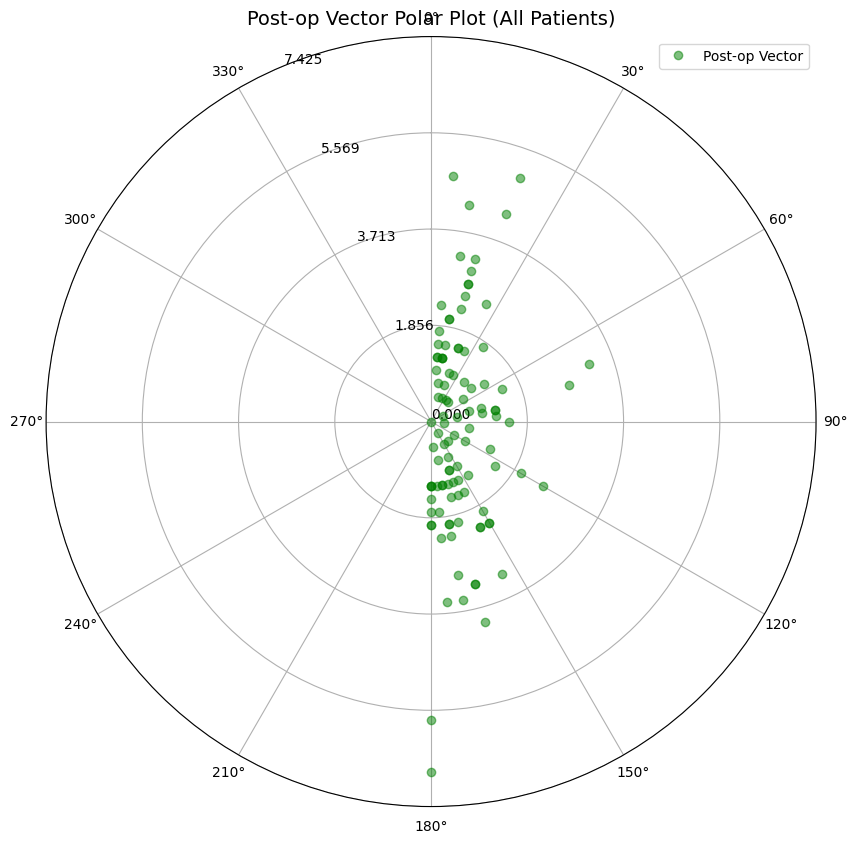

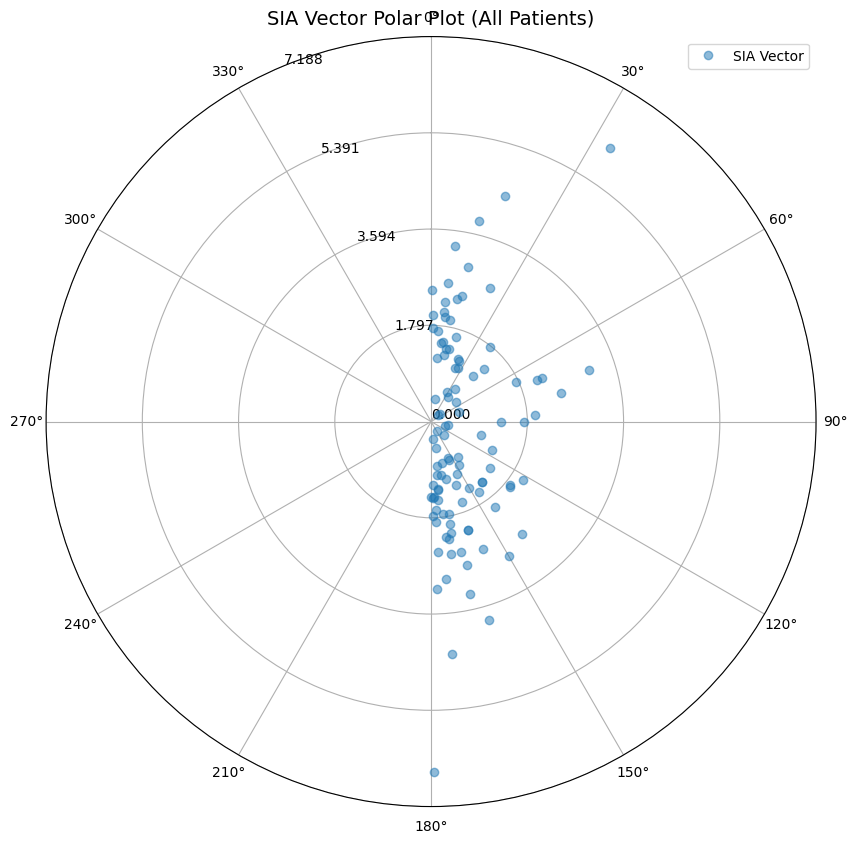

In [64]:
# prompt: Preop post op sia vector plot

import matplotlib.pyplot as plt
import numpy as np
# Pre-op Vector Plot

# Calculate pre-op vector components
df_plot['preop_X'] = df_plot['M1'] * np.cos(2 * np.deg2rad(df_plot['pre-op Axis']))
df_plot['preop_Y'] = df_plot['M1'] * np.sin(2 * np.deg2rad(df_plot['pre-op Axis']))

# Calculate pre-op magnitude and axis (optional, already have M1 and 'pre-op Axis')
# For consistency in plotting, let's work with M1 and the original axis

# Create a polar plot for pre-op vectors
plt.figure(figsize=(10, 10))
ax_preop = plt.subplot(111, projection='polar')

# Plot each patient's pre-op vector as a point
ax_preop.plot(np.deg2rad(df_plot['pre-op Axis']), df_plot['M1'], 'o', alpha=0.5, label='Pre-op Vector')

# Set the plot limits and labels
ax_preop.set_theta_zero_location("N")  # Set 0 degrees to the top
ax_preop.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
ax_preop.set_thetagrids(np.arange(0, 360, 30)) # Set grid lines at 30 degree intervals
ax_preop.set_rlabel_position(-22.5)      # Position radial labels
ax_preop.set_title("Pre-op Vector Polar Plot (All Patients)", va='bottom', fontsize=14)
ax_preop.legend(loc='upper right')

# Set radial limits (magnitude)
max_preop_magnitude = df_plot['M1'].max() if not df_plot['M1'].empty else 1.0
ax_preop.set_rmax(max_preop_magnitude * 1.1)
ax_preop.set_rgrids(np.linspace(0, max_preop_magnitude * 1.1, 5))

ax_preop.grid(True)
plt.show()


# Post-op Vector Plot

# Calculate post-op vector components (already have X2, Y2)
# Calculate post-op magnitude and axis (optional, already have M2 and 'post-op Axis')
# For consistency in plotting, let's work with M2 and the original axis

# Create a polar plot for post-op vectors
plt.figure(figsize=(10, 10))
ax_postop = plt.subplot(111, projection='polar')

# Plot each patient's post-op vector as a point
ax_postop.plot(np.deg2rad(df_plot['post-op Axis']), df_plot['M2'], 'o', alpha=0.5, label='Post-op Vector', color='green')

# Set the plot limits and labels
ax_postop.set_theta_zero_location("N")  # Set 0 degrees to the top
ax_postop.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
ax_postop.set_thetagrids(np.arange(0, 360, 30)) # Set grid lines at 30 degree intervals
ax_postop.set_rlabel_position(-22.5)      # Position radial labels
ax_postop.set_title("Post-op Vector Polar Plot (All Patients)", va='bottom', fontsize=14)
ax_postop.legend(loc='upper right')

# Set radial limits (magnitude)
max_postop_magnitude = df_plot['M2'].max() if not df_plot['M2'].empty else 1.0
ax_postop.set_rmax(max_postop_magnitude * 1.1)
ax_postop.set_rgrids(np.linspace(0, max_postop_magnitude * 1.1, 5))

ax_postop.grid(True)
plt.show()


# SIA Vector Plot (Already present in the original code, reproduced here for completeness)

# Polar plot displaying SIA magnitude and axis for all patients

# Convert SIA axis from degrees to radians for polar plot
# Ensure 'sia_axis' and 'SIA_magnitude' columns exist and are not NaN
# df_plot is already created and cleaned above

# Create a polar plot
plt.figure(figsize=(10, 10))
ax_sia = plt.subplot(111, projection='polar')

# Plot each patient's SIA vector as a point
# Use a marker to indicate each data point
ax_sia.plot(df_plot['sia_axis_rad'], df_plot['SIA_magnitude'], 'o', alpha=0.5, label='SIA Vector') # 'o' for circle marker, alpha for transparency


# Set the plot limits and labels
ax_sia.set_theta_zero_location("N")  # Set 0 degrees to the top
ax_sia.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
# Set thetagrids to cover the 0-180 range and potentially 180-360 if vectors can point there
# Assuming 0-180 is sufficient based on the calculation, but showing 0-360 for clarity of the polar plane
ax_sia.set_thetagrids(np.arange(0, 360, 30)) # Set grid lines at 30 degree intervals from 0 to 360
ax_sia.set_rlabel_position(-22.5)      # Position radial labels
ax_sia.set_title("SIA Vector Polar Plot (All Patients)", va='bottom', fontsize=14)
ax_sia.legend(loc='upper right') # Add legend

# Set radial limits (magnitude)
# Adjust based on your data's magnitude range
# Set max radial limit slightly above the max magnitude in your data
max_sia_magnitude = df_plot['SIA_magnitude'].max() if not df_plot['SIA_magnitude'].empty else 1.0
ax_sia.set_rmax(max_sia_magnitude * 1.1)
ax_sia.set_rgrids(np.linspace(0, max_sia_magnitude * 1.1, 5)) # Set radial grid lines

ax_sia.grid(True)

plt.show()

In [66]:
# prompt: Best predictive model equation for sia vector

print("\nSummary of Model Performance (R-squared Scores):")
print(f"Linear Regression (SIA Magnitude): R-squared = {r2:.4f}")
print(f"Random Forest (SIA Magnitude): R-squared = {r2_rf:.4f}")
print(f"SVR (SIA Magnitude): R-squared = {r2_svm:.4f}")
print(f"Decision Tree (SIA Magnitude): R-squared = {r2_dt:.4f}")
print(f"KNN (SIA Magnitude): R-squared = {r2_knn:.4f}")
print(f"XGBoost (SIA Magnitude): R-squared = {r2_xgb:.4f}")
print(f"Polynomial Regression (degree=2, SIA Magnitude): R-squared = {r2_poly:.4f}")
print("-" * 30)
print(f"Linear Regression (SIA Axis): R-squared = {r2_axis:.4f}")
print(f"Random Forest (SIA Axis): R-squared = {r2_axis_rf:.4f}")
print(f"SVR (SIA Axis): R-squared = {r2_axis_svm:.4f}")
print(f"Decision Tree (SIA Axis): R-squared = {r2_axis_dt:.4f}")
print(f"KNN (SIA Axis): R-squared = {r2_axis_knn:.4f}")
print(f"XGBoost (SIA Axis): R-squared = {r2_axis_xgb:.4f}")

# Based on the R-squared values printed above:
# The model with the highest R-squared for SIA Magnitude is likely the best predictive model for SIA magnitude.
# The model with the highest R-squared for SIA Axis is likely the best predictive model for SIA axis.

# Identify the best model for SIA Magnitude
best_r2_magnitude = max(r2, r2_rf, r2_svm, r2_dt, r2_knn, r2_xgb, r2_poly)
best_model_magnitude = ""

if r2 == best_r2_magnitude:
  best_model_magnitude = "Linear Regression"
elif r2_rf == best_r2_magnitude:
  best_model_magnitude = "Random Forest"
elif r2_svm == best_r2_magnitude:
  best_model_magnitude = "SVR"
elif r2_dt == best_r2_magnitude:
  best_model_magnitude = "Decision Tree"
elif r2_knn == best_r2_magnitude:
  best_model_magnitude = "KNN"
elif r2_xgb == best_r2_magnitude:
  best_model_magnitude = "XGBoost"
elif r2_poly == best_r2_magnitude:
  best_model_magnitude = "Polynomial Regression (degree=2)"

print(f"\nBest predictive model for SIA Magnitude: {best_model_magnitude} (R-squared = {best_r2_magnitude:.4f})")


# Identify the best model for SIA Axis
best_r2_axis = max(r2_axis, r2_axis_rf, r2_axis_svm, r2_axis_dt, r2_axis_knn, r2_axis_xgb)
best_model_axis = ""

if r2_axis == best_r2_axis:
  best_model_axis = "Linear Regression"
elif r2_axis_rf == best_r2_axis:
  best_model_axis = "Random Forest"
elif r2_axis_svm == best_r2_axis:
  best_model_axis = "SVR"
elif r2_axis_dt == best_r2_axis:
  best_model_axis = "Decision Tree"
elif r2_axis_knn == best_r2_axis:
  best_model_axis = "KNN"
elif r2_axis_xgb == best_r2_axis:
  best_model_axis = "XGBoost"

print(f"Best predictive model for SIA Axis: {best_model_axis} (R-squared = {best_r2_axis:.4f})")


# The "best predictive model equation" depends on the specific model identified as best.
# For linear models, the equation is straightforward (linear combination of features).
# For tree-based models (Random Forest, Decision Tree, XGBoost), the "equation" is the structure of the tree(s).
# For SVM and KNN, the model is not easily represented as a simple algebraic equation.
# For Polynomial Regression, the equation is a linear combination of polynomial features.

# Example of how to get the "equation" for Linear Regression (if it's the best for magnitude)
if best_model_magnitude == "Linear Regression":
  print("\nLinear Regression Equation for SIA Magnitude:")
  equation = f"SIA_magnitude = {model.intercept_:.4f}"
  for i, feature in enumerate(X.columns):
    equation += f" + ({model.coef_[i]:.4f} * {feature})"
  print(equation)

# Example of how to get the "equation" for Polynomial Regression (if it's the best for magnitude)
# This will be more complex due to the polynomial features
# if best_model_magnitude == "Polynomial Regression (degree=2)":
#   print("\nPolynomial Regression (degree=2) Equation for SIA Magnitude:")
#   # Getting the polynomial features names can be complex, especially with interactions
#   # You would need to access poly_features.get_feature_names_out(X_poly.columns)
#   # and match them to the coefficients from poly_model.coef_
#   # For simplicity, we'll just show the coefficients here.
#   print("Intercept:", poly_model.intercept_)
#   print("Coefficients for Polynomial Features:", poly_model.coef_)
#   # To write the full equation, you would need to map coefficients to feature names
#   # derived from the original features and their interactions/powers.

# Example of how to get the "equation" for Linear Regression (if it's the best for axis)
if best_model_axis == "Linear Regression":
    print("\nLinear Regression Equation for SIA Axis:")
    equation_axis = f"SIA_axis = {model_axis.intercept_:.4f}"
    for i, feature in enumerate(X_axis.columns):
        equation_axis += f" + ({model_axis.coef_[i]:.4f} * {feature})"




Summary of Model Performance (R-squared Scores):
Linear Regression (SIA Magnitude): R-squared = 0.2748
Random Forest (SIA Magnitude): R-squared = 0.4481
SVR (SIA Magnitude): R-squared = 0.3867
Decision Tree (SIA Magnitude): R-squared = 0.1393
KNN (SIA Magnitude): R-squared = -0.0040
XGBoost (SIA Magnitude): R-squared = 0.4777
Polynomial Regression (degree=2, SIA Magnitude): R-squared = 0.3793
------------------------------
Linear Regression (SIA Axis): R-squared = 0.2272
Random Forest (SIA Axis): R-squared = 0.6171
SVR (SIA Axis): R-squared = 0.0829
Decision Tree (SIA Axis): R-squared = 0.4043
KNN (SIA Axis): R-squared = 0.2462
XGBoost (SIA Axis): R-squared = 0.5490

Best predictive model for SIA Magnitude: XGBoost (R-squared = 0.4777)
Best predictive model for SIA Axis: Random Forest (R-squared = 0.6171)


In [68]:
# prompt: Model equation

import statsmodels.api as sm

# OLS model to predict SIA_magnitude
# Use the cleaned data frame df_cleaned from previous magnitude modeling
# Define the features (independent variables) and the target (dependent variable)
X_ols_magnitude = df_cleaned[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_ols_magnitude = df_cleaned['SIA_magnitude'] # Target

# Add a constant to the independent variables (for the intercept)
X_ols_magnitude = sm.add_constant(X_ols_magnitude)

# Create and fit the OLS model
ols_model_magnitude = sm.OLS(y_ols_magnitude, X_ols_magnitude)
ols_results_magnitude = ols_model_magnitude.fit()

# Print the summary of the OLS regression results for SIA Magnitude
print("\nOLS Regression Results for SIA Magnitude:")
print(ols_results_magnitude.summary())

# OLS model to predict SIA_axis
# Use the cleaned data frame df_cleaned_axis from previous axis modeling
# Define the features (independent variables) and the target (dependent variable)
X_ols_axis = df_cleaned_axis[['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']] # Features
y_ols_axis = df_cleaned_axis['sia_axis'] # Target is sia_axis

# Add a constant to the independent variables (for the intercept)
X_ols_axis = sm.add_constant(X_ols_axis)

# Create and fit the OLS model
ols_model_axis = sm.OLS(y_ols_axis, X_ols_axis)
ols_results_axis = ols_model_axis.fit()

# Print the summary of the OLS regression results for SIA Axis
print("\nOLS Regression Results for SIA Axis:")
print(ols_results_axis.summary())

# You can extract the equation from the OLS summary if needed
# For Magnitude:
# SIA_magnitude = intercept + coef1*feature1 + coef2*feature2 + ...
# print("\nOLS Equation for SIA Magnitude:")
# print(f"SIA_magnitude = {ols_results_magnitude.params['const']:.4f}", end="")
# for i, col in enumerate(X_ols_magnitude.columns[1:]):
#     print(f" + ({ols_results_magnitude.params[col]:.4f} * {col})", end="")
# print() # Add a newline at the end

# For Axis:
# SIA_axis = intercept + coef1*feature1 + coef2*feature2 + ...
# print("\nOLS Equation for SIA Axis:")
# print(f"SIA_axis = {ols_results_axis.params['const']:.4f}", end="")
# for i, col in enumerate(X_ols_axis.columns[1:]):
#     print(f" + ({ols_results_axis.params[col]:.4f} * {col})", end="")
# print() # Add a newline at the end



OLS Regression Results for SIA Magnitude:
                            OLS Regression Results                            
Dep. Variable:          SIA_magnitude   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     17.53
Date:                Tue, 01 Jul 2025   Prob (F-statistic):           9.01e-14
Time:                        17:24:53   Log-Likelihood:                -121.74
No. Observations:                 107   AIC:                             257.5
Df Residuals:                     100   BIC:                             276.2
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const


Centroid (Mean SIA Vector Components):
  Mean Xsia: 1.0514
  Mean Ysia: -0.0557

Centroid (Mean SIA Vector):
  Magnitude: 1.0528 Diopters
  Axis (0-360 degrees): -3.03 degrees
  Axis (Adjusted 0-180 degrees): 176.97 degrees


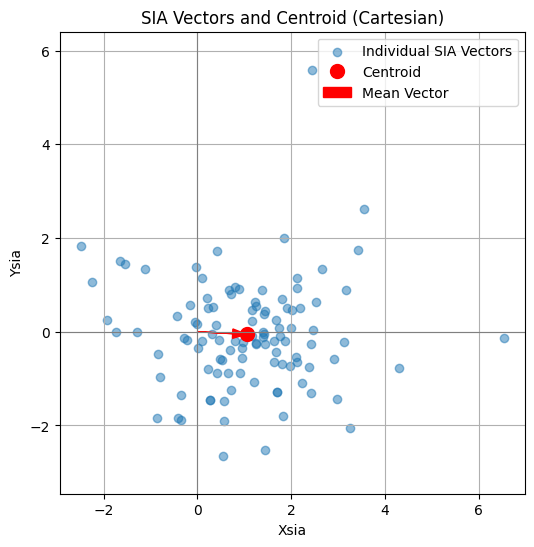

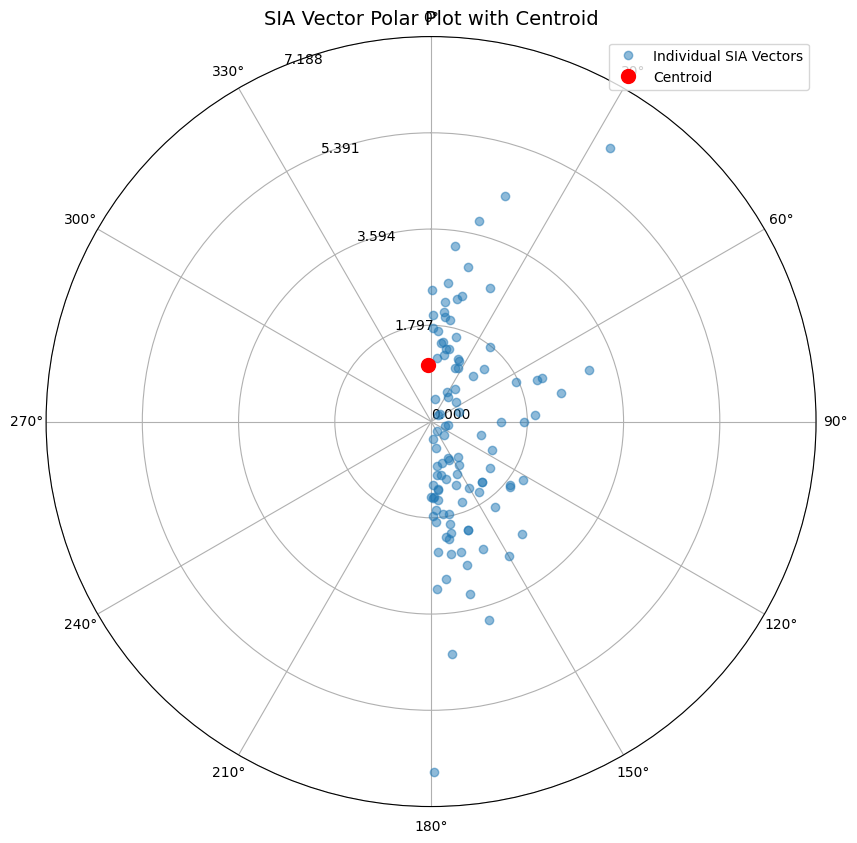

In [72]:
# prompt: Centroid

import matplotlib.pyplot as plt
import numpy as np
# Calculate the mean Xsia and mean Ysia
mean_Xsia = df['Xsia'].mean()
mean_Ysia = df['Ysia'].mean()

# The centroid of the vector distribution is (mean_Xsia, mean_Ysia) in the Cartesian plane.
print(f"\nCentroid (Mean SIA Vector Components):")
print(f"  Mean Xsia: {mean_Xsia:.4f}")
print(f"  Mean Ysia: {mean_Ysia:.4f}")

# Optional: Calculate the magnitude and axis of the mean vector (the centroid vector)
centroid_magnitude = np.sqrt(mean_Xsia**2 + mean_Ysia**2)

# Use arctan2 for the angle of the mean vector, and adjust to 0-180 range if needed
# The angle of the mean vector is typically reported as is, but if you want it in the 0-180 format of SIA axis:
centroid_axis_rad = np.arctan2(mean_Ysia, mean_Xsia)
centroid_axis_deg = np.rad2deg(centroid_axis_rad)
centroid_axis_deg_adjusted = centroid_axis_deg % 180 # Adjust to 0-180 range

print(f"\nCentroid (Mean SIA Vector):")
print(f"  Magnitude: {centroid_magnitude:.4f} Diopters")
print(f"  Axis (0-360 degrees): {centroid_axis_deg:.2f} degrees")
print(f"  Axis (Adjusted 0-180 degrees): {centroid_axis_deg_adjusted:.2f} degrees")

# Optional: Plot the centroid on the Cartesian and Polar plots

# Plotting the centroid on the Cartesian plot
plt.figure(figsize=(6, 6))
plt.scatter(df['Xsia'], df['Ysia'], alpha=0.5, label='Individual SIA Vectors') # Plot individual points
plt.plot(mean_Xsia, mean_Ysia, 'ro', markersize=10, label='Centroid') # Plot the centroid in red
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean Vector') # Plot the mean vector
plt.xlabel('Xsia')
plt.ylabel('Ysia')
plt.title('SIA Vectors and Centroid (Cartesian)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling for X and Y axes
plt.legend()
plt.show()

# Plotting the centroid on the Polar plot (on the SIA Vector Polar Plot)

# Recreate the polar plot for SIA vectors
plt.figure(figsize=(10, 10))
ax_centroid_polar = plt.subplot(111, projection='polar')

# Plot each patient's SIA vector as a point
ax_centroid_polar.plot(df_plot['sia_axis_rad'], df_plot['SIA_magnitude'], 'o', alpha=0.5, label='Individual SIA Vectors')

# Plot the centroid vector
ax_centroid_polar.plot(centroid_axis_rad, centroid_magnitude, 'ro', markersize=10, label='Centroid')
# Optionally draw an arrow for the centroid
# ax_centroid_polar.arrow(0, 0, centroid_axis_rad, centroid_magnitude, head_width=0.05 * centroid_magnitude, head_length=0.1 * centroid_magnitude, fc='red', ec='red', length_includes_head=True)


# Set the plot limits and labels
ax_centroid_polar.set_theta_zero_location("N")  # Set 0 degrees to the top
ax_centroid_polar.set_theta_direction(-1)       # Go clockwise for axis (0 to 180)
ax_centroid_polar.set_thetagrids(np.arange(0, 360, 30)) # Set grid lines at 30 degree intervals
ax_centroid_polar.set_rlabel_position(-22.5)      # Position radial labels
ax_centroid_polar.set_title("SIA Vector Polar Plot with Centroid", va='bottom', fontsize=14)
ax_centroid_polar.legend(loc='upper right')

# Set radial limits (magnitude)
max_magnitude = df_plot['SIA_magnitude'].max() if not df_plot['SIA_magnitude'].empty else 1.0
# Ensure the centroid magnitude is also considered for setting the limit
overall_max_magnitude = max(max_magnitude, centroid_magnitude)
ax_centroid_polar.set_rmax(overall_max_magnitude * 1.1)
ax_centroid_polar.set_rgrids(np.linspace(0, overall_max_magnitude * 1.1, 5)) # Set radial grid lines

ax_centroid_polar.grid(True)

plt.show()

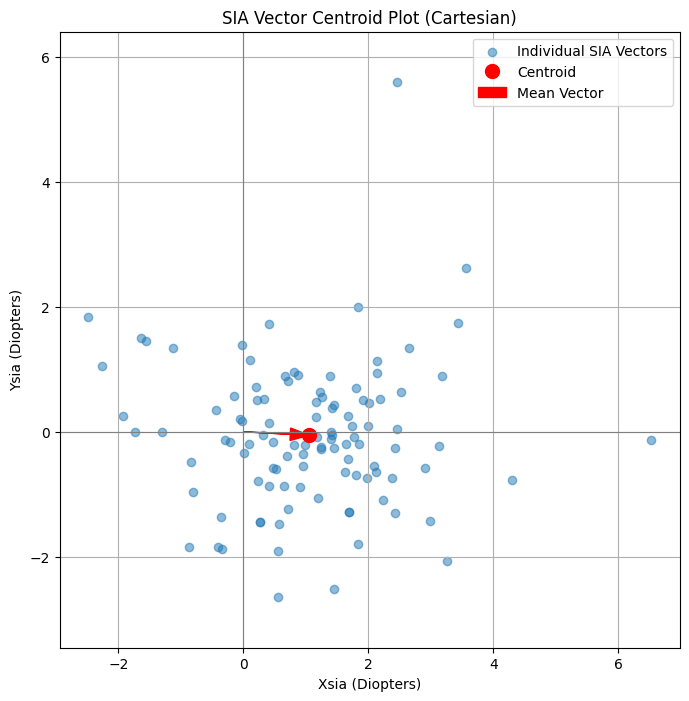

In [73]:
# prompt: Centroid plot

import matplotlib.pyplot as plt
# Plotting the centroid on the Cartesian plot
plt.figure(figsize=(8, 8))
plt.scatter(df['Xsia'], df['Ysia'], alpha=0.5, label='Individual SIA Vectors') # Plot individual points
plt.plot(mean_Xsia, mean_Ysia, 'ro', markersize=10, label='Centroid') # Plot the centroid in red
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean Vector') # Plot the mean vector
plt.xlabel('Xsia (Diopters)')
plt.ylabel('Ysia (Diopters)')
plt.title('SIA Vector Centroid Plot (Cartesian)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling for X and Y axes
plt.legend()
plt.show()

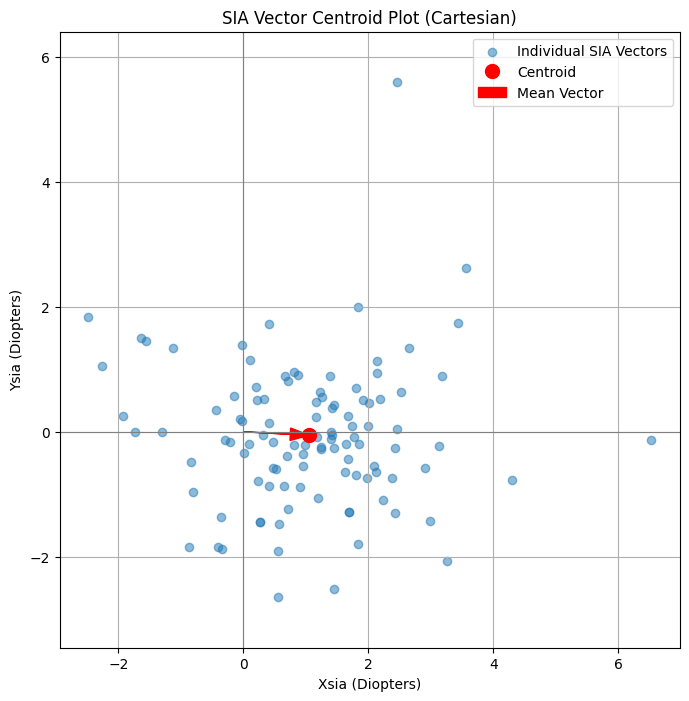

In [74]:
# prompt: Plot centroid

import matplotlib.pyplot as plt
# Plotting the centroid on the Cartesian plot
plt.figure(figsize=(8, 8))
plt.scatter(df['Xsia'], df['Ysia'], alpha=0.5, label='Individual SIA Vectors') # Plot individual points
plt.plot(mean_Xsia, mean_Ysia, 'ro', markersize=10, label='Centroid') # Plot the centroid in red
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean Vector') # Plot the mean vector
plt.xlabel('Xsia (Diopters)')
plt.ylabel('Ysia (Diopters)')
plt.title('SIA Vector Centroid Plot (Cartesian)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling for X and Y axes
plt.legend()
plt.show()



SIA Vector Variability:
  Vector Variance (Mean Squared Error from Centroid): 3.2538 Diopters^2
  Standard Vector Deviation (SD-SIA): 1.8038 Diopters


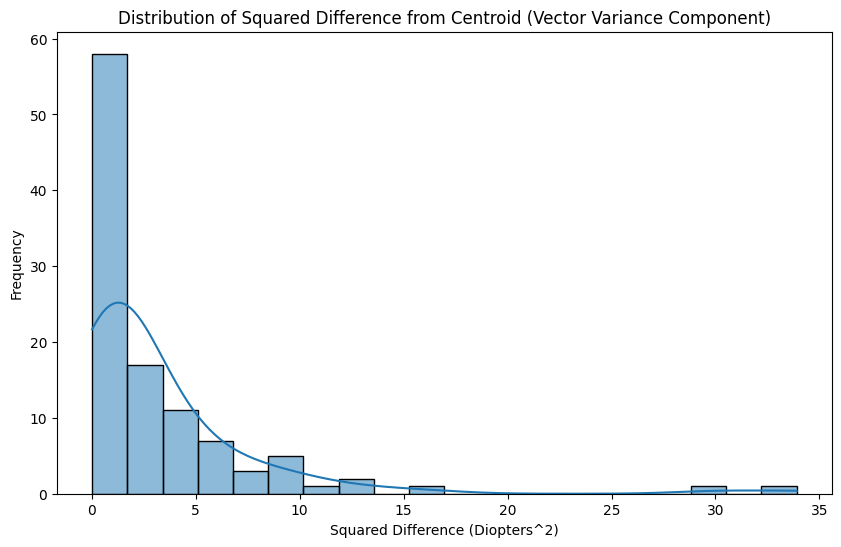

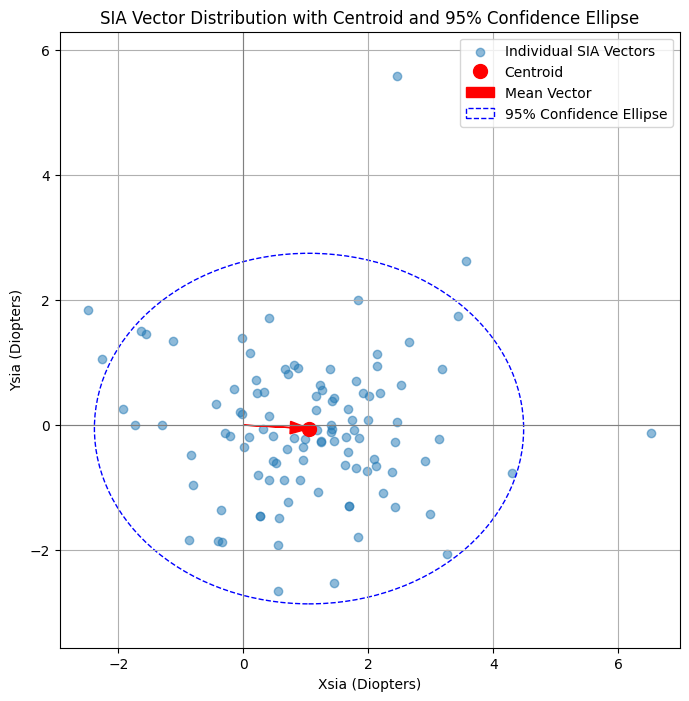

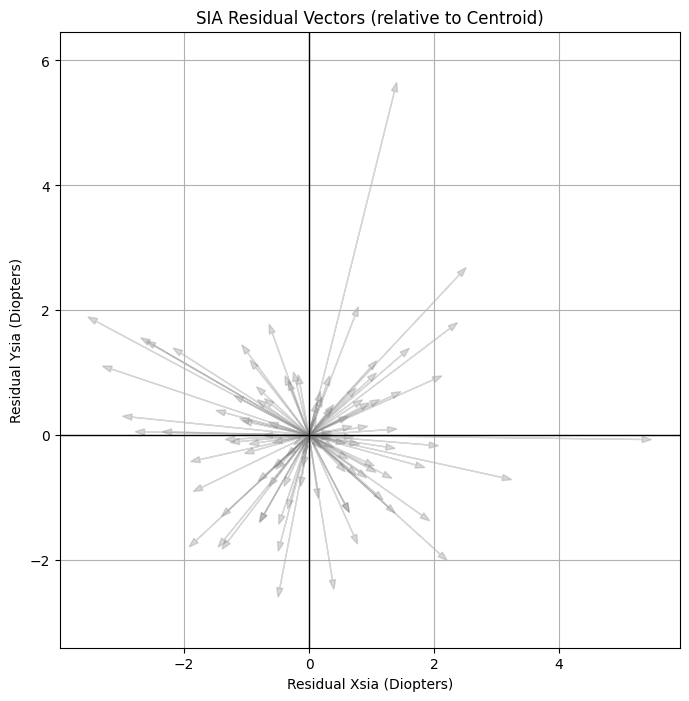

In [78]:
# prompt: Any other visualisation

import matplotlib.pyplot as plt
import numpy as np
# Calculate the variance of SIA vectors
# The variance is the mean squared difference from the centroid (mean vector)

# Calculate the squared difference for each vector component
df['Xsia_diff_sq'] = (df['Xsia'] - mean_Xsia)**2
df['Ysia_diff_sq'] = (df['Ysia'] - mean_Ysia)**2

# Calculate the mean of the squared differences
# This is essentially the variance in X and Y components, but the vector variance is usually
# represented by the mean squared error from the centroid in 2D space.
# Vector variance (or mean squared error from centroid) = Mean of (Xsia_diff_sq + Ysia_diff_sq)

# Calculate the squared magnitude of the difference from the centroid for each point
df['vector_diff_sq'] = df['Xsia_diff_sq'] + df['Ysia_diff_sq']

# Calculate the mean squared error from the centroid (this is the vector variance)
vector_variance = df['vector_diff_sq'].mean()

# The standard deviation is the square root of the variance (Standard Vector Deviation or SD-SIA)
standard_vector_deviation = np.sqrt(vector_variance)

print(f"\nSIA Vector Variability:")
print(f"  Vector Variance (Mean Squared Error from Centroid): {vector_variance:.4f} Diopters^2")
print(f"  Standard Vector Deviation (SD-SIA): {standard_vector_deviation:.4f} Diopters")

# Optional: Plot the distribution of the squared difference from the centroid
plt.figure(figsize=(10, 6))
sns.histplot(df['vector_diff_sq'], kde=True, bins=20)
plt.title('Distribution of Squared Difference from Centroid (Vector Variance Component)')
plt.xlabel('Squared Difference (Diopters^2)')
plt.ylabel('Frequency')
plt.show()

# Another common visualization for vector data variability is an ellipse of confidence
# around the centroid in the Cartesian plot. This requires calculating the covariance matrix.

# Calculate the covariance matrix of Xsia and Ysia
covariance_matrix = np.cov(df[['Xsia', 'Ysia']].T)

# Eigenvalues and eigenvectors of the covariance matrix describe the variance in the directions
# of maximum and minimum variance.
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# The eigenvalues are the variances along the principal axes
variance_major = eigenvalues[0]
variance_minor = eigenvalues[1]

# The eigenvectors are the directions of the principal axes
eigenvector_major = eigenvectors[:, 0]
eigenvector_minor = eigenvectors[:, 1]

# We can use these to plot an ellipse representing confidence regions.
# A common practice is to plot an ellipse that contains a certain percentage of the data (e.g., 95%)
# For a 2D Gaussian distribution, the squared Mahalanobis distance follows a chi-squared distribution with 2 degrees of freedom.
# The 95% confidence ellipse is given by Mahalanobis distance squared = chi2(2, 0.95) = 5.991

from matplotlib.patches import Ellipse

# Function to plot the ellipse
def plot_ellipse(centroid_x, centroid_y, cov, ax, confidence_level=0.95, **kwargs):
    """
    Plots a confidence ellipse on a 2D plot.
    centroid_x, centroid_y: Coordinates of the ellipse center (mean Xsia, mean Ysia)
    cov: The 2x2 covariance matrix of Xsia and Ysia
    ax: The matplotlib axes to plot on
    confidence_level: The confidence level for the ellipse (e.g., 0.95 for 95%)
    kwargs: Additional keyword arguments for the Ellipse patch
    """
    from scipy.stats import chi2

    # Get eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov)

    # The angles of the ellipse are given by the eigenvectors
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # The lengths of the axes of the ellipse are proportional to the square root of the eigenvalues
    # scaled by the square root of the chi-squared value for the desired confidence level.
    chi2_val = chi2.ppf(confidence_level, df=2) # 2 degrees of freedom for a 2D ellipse
    width, height = 2 * np.sqrt(chi2_val * eigenvalues)

    # Create the ellipse patch
    ellipse = Ellipse((centroid_x, centroid_y), width=width, height=height,
                      angle=angle, fill=False, **kwargs)

    ax.add_patch(ellipse)
    return ellipse


# Plotting the SIA vectors, centroid, and confidence ellipse
plt.figure(figsize=(8, 8))
ax_ellipse = plt.subplot(111)

# Plot individual SIA vectors
ax_ellipse.scatter(df['Xsia'], df['Ysia'], alpha=0.5, label='Individual SIA Vectors')

# Plot the centroid
ax_ellipse.plot(mean_Xsia, mean_Ysia, 'ro', markersize=10, label='Centroid')

# Plot the mean vector (arrow)
ax_ellipse.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean Vector')

# Plot the 95% confidence ellipse
plot_ellipse(mean_Xsia, mean_Ysia, covariance_matrix, ax_ellipse, confidence_level=0.95, color='blue', linestyle='--', label='95% Confidence Ellipse')

plt.xlabel('Xsia (Diopters)')
plt.ylabel('Ysia (Diopters)')
plt.title('SIA Vector Distribution with Centroid and 95% Confidence Ellipse')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling
plt.legend()
plt.show()


# If you want to visualize the residual vectors (the difference between each vector and the mean vector)
# This shows the spread around the centroid.

df['Residual_Xsia'] = df['Xsia'] - mean_Xsia
df['Residual_Ysia'] = df['Ysia'] - mean_Ysia

plt.figure(figsize=(8, 8))
ax_residuals = plt.subplot(111)

# Plot the residual vectors originating from the origin (the centroid is now the origin in this view)
for i in range(len(df)):
    ax_residuals.arrow(0, 0, df.iloc[i]['Residual_Xsia'], df.iloc[i]['Residual_Ysia'],
                       head_width=0.1, head_length=0.15, fc='gray', ec='gray', length_includes_head=True, alpha=0.3)

plt.xlabel('Residual Xsia (Diopters)')
plt.ylabel('Residual Ysia (Diopters)')
plt.title('SIA Residual Vectors (relative to Centroid)')
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.axis('equal') # Ensure equal scaling
plt.show()

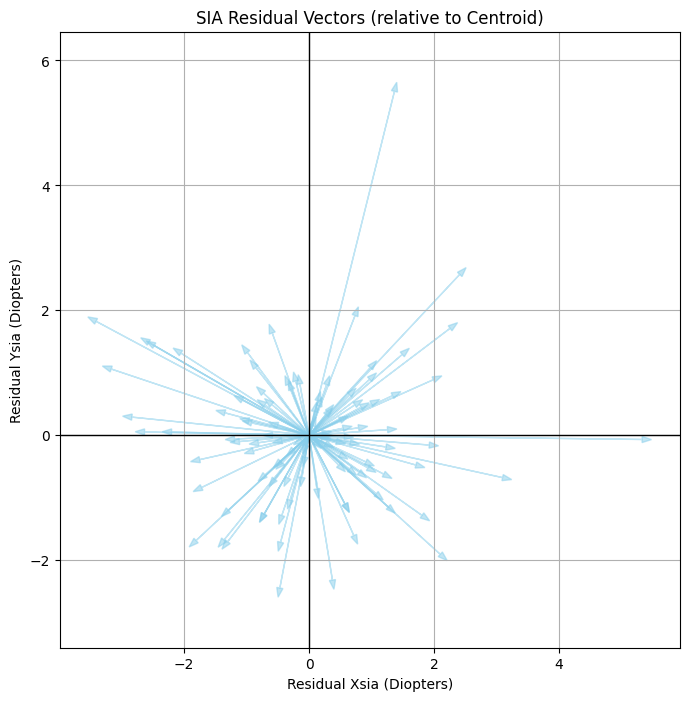

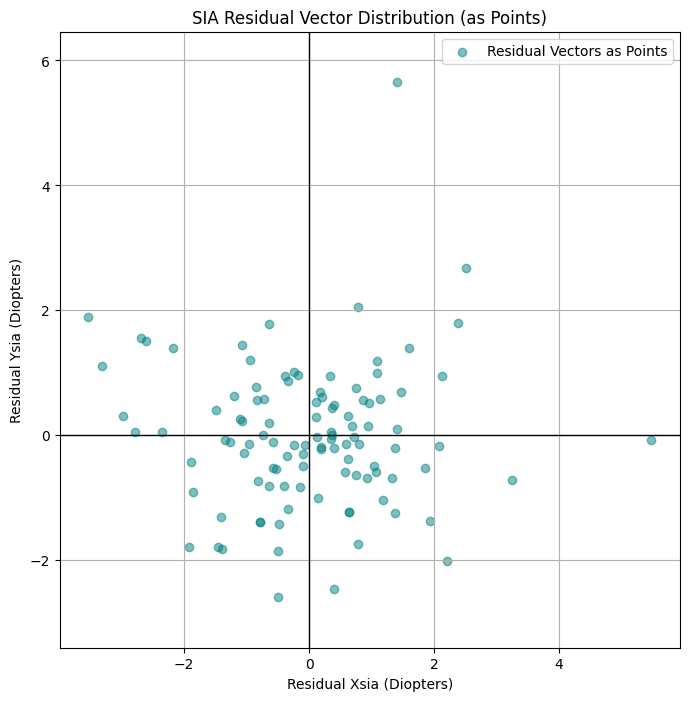

In [83]:
# prompt: Residual vector plots color

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
ax_residuals = plt.subplot(111)

# Plot the residual vectors originating from the origin (the centroid is now the origin in this view)
for i in range(len(df)):
    ax_residuals.arrow(0, 0, df.iloc[i]['Residual_Xsia'], df.iloc[i]['Residual_Ysia'],
                       head_width=0.1, head_length=0.15, fc='teal', ec='teal', length_includes_head=True, alpha=0.5) # Changed color to teal and alpha to 0.5

plt.xlabel('Residual Xsia (Diopters)')
plt.ylabel('Residual Ysia (Diopters)')
plt.title('SIA Residual Vectors (relative to Centroid)')
plt.grid(True)
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.axis('equal') # Ensure equal scaling
plt.show()

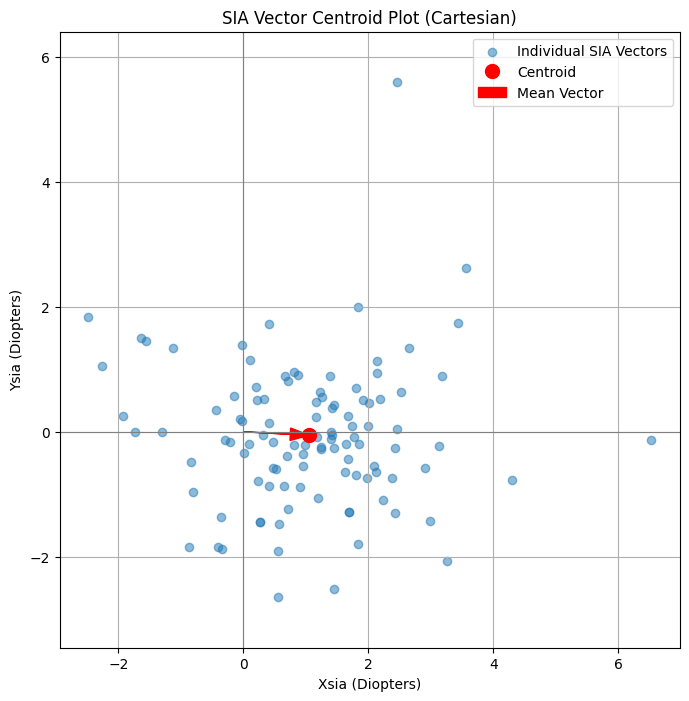

In [88]:
# prompt: Centroid plot

import matplotlib.pyplot as plt
# Centroid plot
plt.figure(figsize=(8, 8))
plt.scatter(df['Xsia'], df['Ysia'], alpha=0.5, label='Individual SIA Vectors') # Plot individual points
plt.plot(mean_Xsia, mean_Ysia, 'ro', markersize=10, label='Centroid') # Plot the centroid in red
plt.arrow(0, 0, mean_Xsia, mean_Ysia, head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean Vector') # Plot the mean vector
plt.xlabel('Xsia (Diopters)')
plt.ylabel('Ysia (Diopters)')
plt.title('SIA Vector Centroid Plot (Cartesian)')
plt.grid(True)
plt.axhline(0, color='grey', lw=0.8)
plt.axvline(0, color='grey', lw=0.8)
plt.axis('equal') # Ensure equal scaling for X and Y axes
plt.legend()
plt.show()

In [89]:
# ✅ Install TensorFlow if not already
!pip install -q tensorflow

# ✅ Imports
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split

# ✅ Generate synthetic dataset
np.random.seed(42)
X = np.random.uniform(low=42.0, high=46.0, size=(1000, 3))  # [Pre_KH, Pre_KV, Pre_Axis]

# Simulate SIA Magnitude (e.g. function of KV - KH)
y_mag = 0.5 + 0.4 * (X[:,1] - X[:,0]) + np.random.normal(0, 0.05, 1000)

# Simulate SIA Axis (e.g. related to Pre-Axis + randomness)
y_axis = (X[:,2] + np.random.normal(0, 5, 1000)) % 180

# ✅ Train-test split
X_train, X_test, y_mag_train, y_mag_test, y_axis_train, y_axis_test = train_test_split(
    X, y_mag, y_axis, test_size=0.2, random_state=42
)

# ✅ Build SIA Magnitude Model
model_mag = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])
model_mag.compile(optimizer='adam', loss='mse')
model_mag.fit(X_train, y_mag_train, epochs=100, verbose=0)

# ✅ Build SIA Axis Model
model_axis = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)
])
model_axis.compile(optimizer='adam', loss='mse')
model_axis.fit(X_train, y_axis_train, epochs=100, verbose=0)

# ✅ Convert to TFLite
def convert_and_save(model, filename):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(filename, 'wb') as f:
        f.write(tflite_model)

convert_and_save(model_mag, 'sia_magnitude_model.tflite')
convert_and_save(model_axis, 'sia_axis_model.tflite')

print("✅ TFLite models created!")

# ✅ Download the models
from google.colab import files
files.download('sia_magnitude_model.tflite')
files.download('sia_axis_model.tflite')


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved artifact at '/tmp/tmp15gxf72f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135609986992464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135609986995728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135609986997648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135609986993232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135609986997840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135609986995344: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved artifact at '/tmp/tmp6hsk3duy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135609987001296: TensorSpec(

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

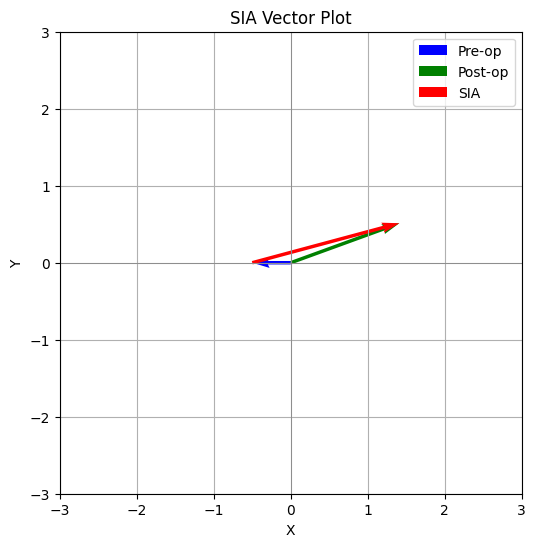

SIA Magnitude: 1.98 D
SIA Axis: 7.52°


In [90]:
import math
import matplotlib.pyplot as plt

def calculate_sia_and_plot(pre_kh, pre_kv, pre_axis, post_kh, post_kv, post_axis):
    # Step 1: Calculate astigmatism magnitudes
    A1 = pre_kv - pre_kh
    A2 = post_kv - post_kh

    # Step 2: Convert axis to double-angle (in radians)
    theta1 = math.radians(2 * pre_axis)
    theta2 = math.radians(2 * post_axis)

    # Step 3: Convert to Cartesian components
    X1 = A1 * math.cos(theta1)
    Y1 = A1 * math.sin(theta1)

    X2 = A2 * math.cos(theta2)
    Y2 = A2 * math.sin(theta2)

    # Step 4: Calculate SIA vector
    X_sia = X2 - X1
    Y_sia = Y2 - Y1

    # Step 5: SIA magnitude and axis
    sia_magnitude = math.sqrt(X_sia**2 + Y_sia**2)
    sia_axis = math.degrees(0.5 * math.atan2(Y_sia, X_sia))
    if sia_axis < 0:
        sia_axis += 180

    # Step 6: Plotting
    plt.figure(figsize=(6, 6))
    plt.quiver(0, 0, X1, Y1, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')
    plt.quiver(0, 0, X2, Y2, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')
    plt.quiver(X1, Y1, X_sia, Y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

    # Format plot
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("SIA Vector Plot")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Print result
    print(f"SIA Magnitude: {sia_magnitude:.2f} D")
    print(f"SIA Axis: {sia_axis:.2f}°")

# Example
calculate_sia_and_plot(
    pre_kh=43.50,
    pre_kv=44.00,
    pre_axis=90,
    post_kh=43.25,
    post_kv=44.75,
    post_axis=10
)


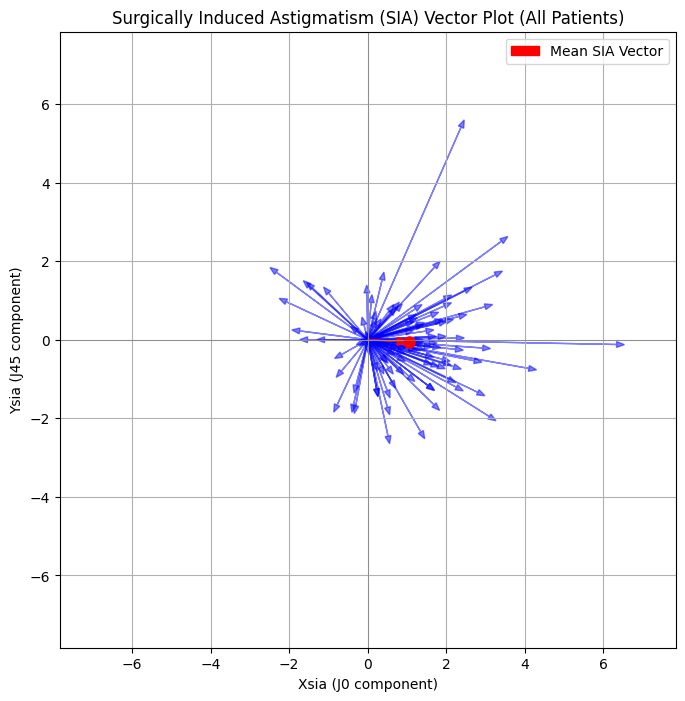


Mean SIA Vector:
  Mean Xsia (J0 component): 1.0514 D
  Mean Ysia (J45 component): -0.0557 D
  Mean SIA Magnitude: 1.0528 D
  Mean SIA Axis (0-180°): 178.48°


In [91]:
# prompt: SIA vector plot

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
def calculate_sia_and_plot_all(df):
    """
    Calculates SIA vectors for all patients in the DataFrame and plots them.

    Args:
        df (pd.DataFrame): DataFrame containing 'pre-op KV', 'pre-op KH',
                           'pre-op Axis', 'post-op KV', 'post-op KH',
                           'post-op Axis' columns.
    """
    # Ensure required columns exist
    required_cols = ['pre-op KV', 'pre-op KH', 'pre-op Axis', 'post-op KV', 'post-op KH', 'post-op Axis']
    if not all(col in df.columns for col in required_cols):
        print("Error: DataFrame is missing one or more required columns for calculation.")
        print(f"Required columns: {required_cols}")
        return

    # Drop rows with any NaN in the relevant columns
    df_cleaned = df.dropna(subset=required_cols).copy()

    # Calculate pre-op and post-op astigmatism magnitudes
    df_cleaned['A1'] = df_cleaned['pre-op KV'] - df_cleaned['pre-op KH']
    df_cleaned['A2'] = df_cleaned['post-op KV'] - df_cleaned['post-op KH']

    # Convert axis to double-angle (in radians)
    df_cleaned['theta1'] = np.deg2rad(2 * df_cleaned['pre-op Axis'])
    df_cleaned['theta2'] = np.deg2rad(2 * df_cleaned['post-op Axis'])

    # Convert to Cartesian components (J0, J45 equivalent in double-angle space)
    # X corresponds to J0 component (astigmatism at 0/90)
    # Y corresponds to J45 component (astigmatism at 45/135)
    df_cleaned['X1'] = df_cleaned['A1'] * np.cos(df_cleaned['theta1'])
    df_cleaned['Y1'] = df_cleaned['A1'] * np.sin(df_cleaned['theta1'])

    df_cleaned['X2'] = df_cleaned['A2'] * np.cos(df_cleaned['theta2'])
    df_cleaned['Y2'] = df_cleaned['A2'] * np.sin(df_cleaned['theta2'])

    # Calculate SIA vector components
    df_cleaned['Xsia'] = df_cleaned['X2'] - df_cleaned['X1']
    df_cleaned['Ysia'] = df_cleaned['Y2'] - df_cleaned['Y1']

    # Plotting SIA vectors
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111)

    # Plot each SIA vector as an arrow starting from the origin
    # We can also plot points if arrows are too cluttered
    for i in range(len(df_cleaned)):
        ax.arrow(0, 0, df_cleaned.iloc[i]['Xsia'], df_cleaned.iloc[i]['Ysia'],
                 head_width=0.15, head_length=0.2, fc='blue', ec='blue', length_includes_head=True, alpha=0.5)

    # Plot the centroid (Mean SIA vector)
    mean_Xsia = df_cleaned['Xsia'].mean()
    mean_Ysia = df_cleaned['Ysia'].mean()
    ax.arrow(0, 0, mean_Xsia, mean_Ysia,
             head_width=0.2, head_length=0.3, fc='red', ec='red', length_includes_head=True, label='Mean SIA Vector')
    ax.plot(mean_Xsia, mean_Ysia, 'ro', markersize=8) # Mark the centroid point

    # Format plot
    max_abs_limit = max(df_cleaned['Xsia'].abs().max(), df_cleaned['Ysia'].abs().max(), abs(mean_Xsia), abs(mean_Ysia)) * 1.2
    plt.xlim(-max_abs_limit, max_abs_limit)
    plt.ylim(-max_abs_limit, max_abs_limit)
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.axvline(0, color='gray', linewidth=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title("Surgically Induced Astigmatism (SIA) Vector Plot (All Patients)")
    plt.xlabel("Xsia (J0 component)")
    plt.ylabel("Ysia (J45 component)")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"\nMean SIA Vector:")
    print(f"  Mean Xsia (J0 component): {mean_Xsia:.4f} D")
    print(f"  Mean Ysia (J45 component): {mean_Ysia:.4f} D")
    mean_sia_magnitude = np.sqrt(mean_Xsia**2 + mean_Ysia**2)
    mean_sia_axis = np.rad2deg(0.5 * np.arctan2(mean_Ysia, mean_Xsia))
    if mean_sia_axis < 0:
        mean_sia_axis += 180
    print(f"  Mean SIA Magnitude: {mean_sia_magnitude:.4f} D")
    print(f"  Mean SIA Axis (0-180°): {mean_sia_axis:.2f}°")


# Call the function to plot SIA vectors for all patients
calculate_sia_and_plot_all(df)
